# RISE 표현체 교육 실습 노트북

> 이 첫 셀은 실습용 주석/목차 셀입니다. PPT에서는 표현체의 개념, 필요성, 데이터 획득 사례, 전체 분석 흐름을 먼저 다루고, 이 노트북에서는 그 흐름 중 **전처리, 객체 분할, 계측**을 직접 실행해 봅니다.

<p>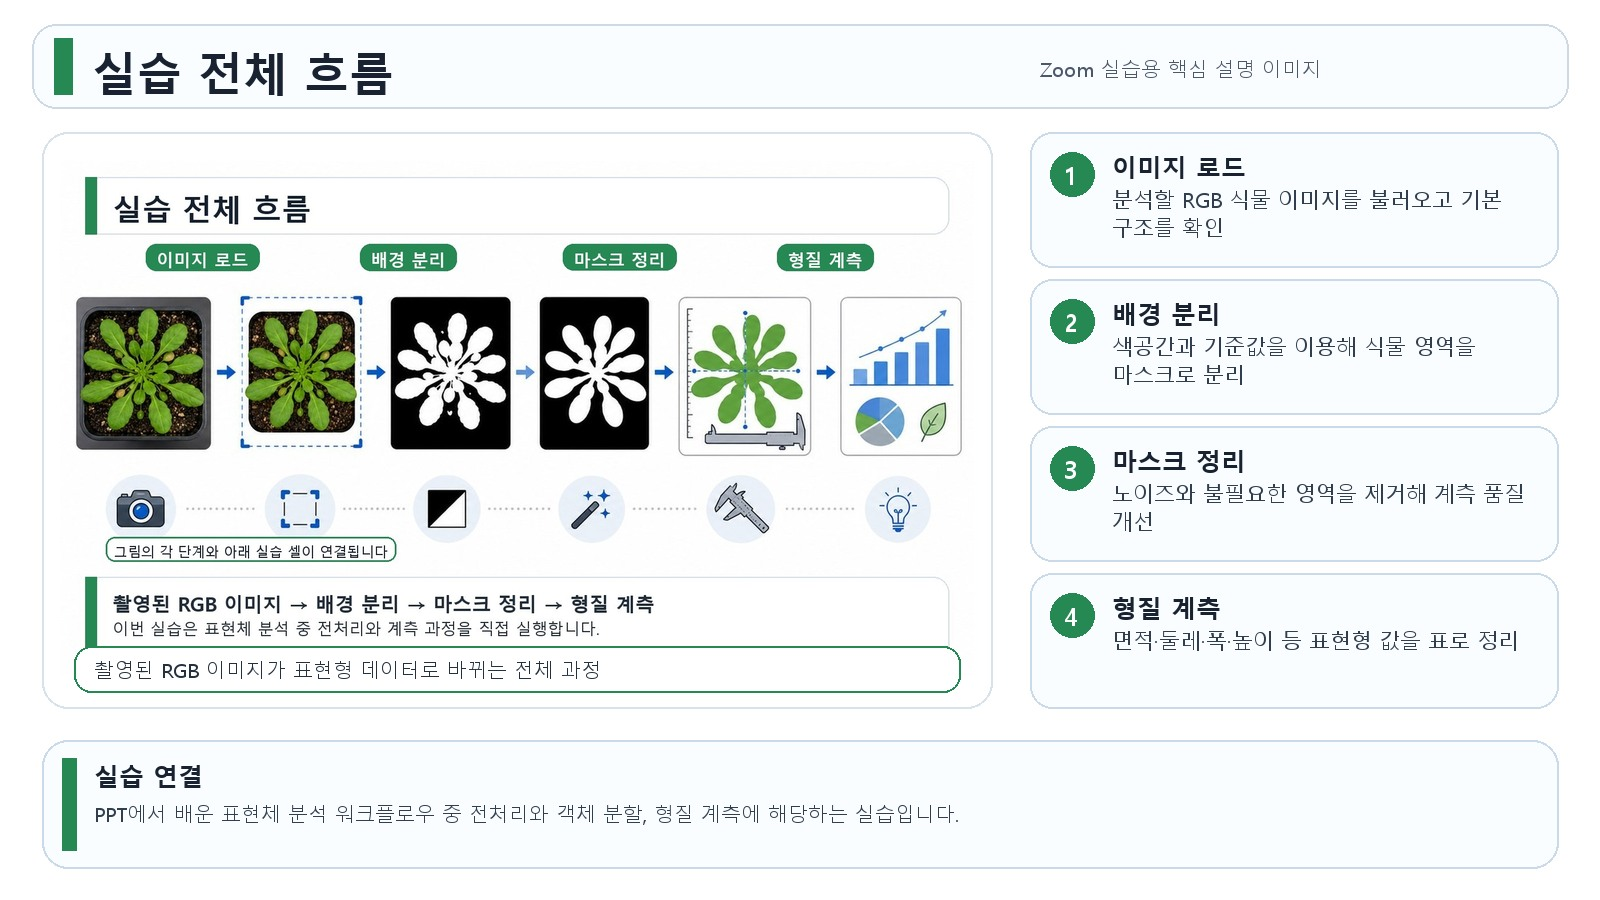</p>
## 오늘 실습의 위치

- **PPT 이론:** 표현형과 표현체, 왜 필요한가, RGB/Depth/초분광 등 데이터 획득, 농업 적용 사례, AI 객체 분할의 한계와 필요성
- **이 노트북 실습:** 이미 촬영된 RGB 이미지에서 배경을 분리하고, 식물체나 병징 영역을 마스크로 만든 뒤, 면적과 둘레 같은 형질을 계측
- **오늘 다루지 않는 것:** 촬영 장비 설계, 대규모 라벨링 프로젝트, 딥러닝 모델 장시간 학습, 통계 모델링 전체 과정

## 실습 목차

1. Colab 실행 환경 준비
2. RGB 이미지 불러오기와 이미지 구조 확인
3. 관심 영역 자르기와 색공간 채널 확인
4. 수동 기준값으로 이진 마스크 만들기
5. 자동 이진화와 적응형 이진화 비교
6. 노이즈 제거, ROI 지정, 식물 형질 계측
7. 지도학습 기반 병징 분할: Naive Bayes
8. 비지도학습 기반 식물 분할: k-means
9. 결과 해석과 다음 단계

## Colab에서 진행하는 방법

- 왼쪽 **목차**에서 섹션을 접고 펼치며 순서대로 진행하세요.
- 각 큰 장 아래에 작은 하위 셀을 두었습니다. 한 번에 모든 코드를 이해하려고 하지 말고, 바로 위 설명을 읽은 뒤 해당 셀만 실행하세요.
- 코드 셀은 대부분 `#@title`, `#@param` 형식의 **Colab Form**입니다. 코드를 직접 수정하지 않고 슬라이더와 입력값을 바꿔 실행할 수 있습니다.
- `ipywidgets`, `ipympl` 같은 브라우저/백엔드 영향을 받는 위젯은 사용하지 않습니다. 값 변경 후 셀을 다시 실행하는 방식이 가장 안정적입니다.
- 각 장의 자세한 설명은 접힌 상자(`<details>`)에 넣어두었습니다. 필요할 때만 펼쳐서 읽으면 됩니다.


## 배포용 실행 안내

**표현체(phenotype)**는 식물의 키, 면적, 색, 병징처럼 관찰하거나 측정할 수 있는 특성입니다. 이 노트북에서는 촬영된 이미지에서 배경을 분리하고, 식물 또는 병징 영역을 마스크로 만든 뒤, 픽셀 단위 형질표를 만드는 과정을 실습합니다.

**오늘의 산출물:** `plant_traits.csv`, `disease_traits.csv`, `kmeans_object_traits.csv`, `rise_results.zip`

**Colab 초심자 실행 순서**
- 우상단 `연결`을 누른 뒤, 셀 왼쪽의 ▶ 버튼 또는 `Shift+Enter`로 위에서 아래로 실행합니다.
- CPU 런타임이면 충분합니다. GPU는 필요하지 않습니다.
- 처음에는 0장 준비 셀을 순서대로 실행하고, 설치/다운로드 메시지를 확인하세요.
- 런타임이 끊기거나 브라우저를 새로 열면 00-1부터 다시 실행하세요.
- 값을 바꿨다면 해당 셀 아래쪽을 다시 실행해야 결과표가 갱신됩니다. 오류 메시지에는 어느 셀부터 다시 실행할지 안내가 들어 있습니다.

**데이터 준비:** 첫 실행에는 인터넷이 필요합니다. 기관망에서 GitHub가 막히는 경우를 대비해, 강사는 이 노트북과 함께 `rise_phenotyping_assets.zip`을 같은 폴더에 올려둘 수 있습니다.


# 0. 실행 환경 준비

<p>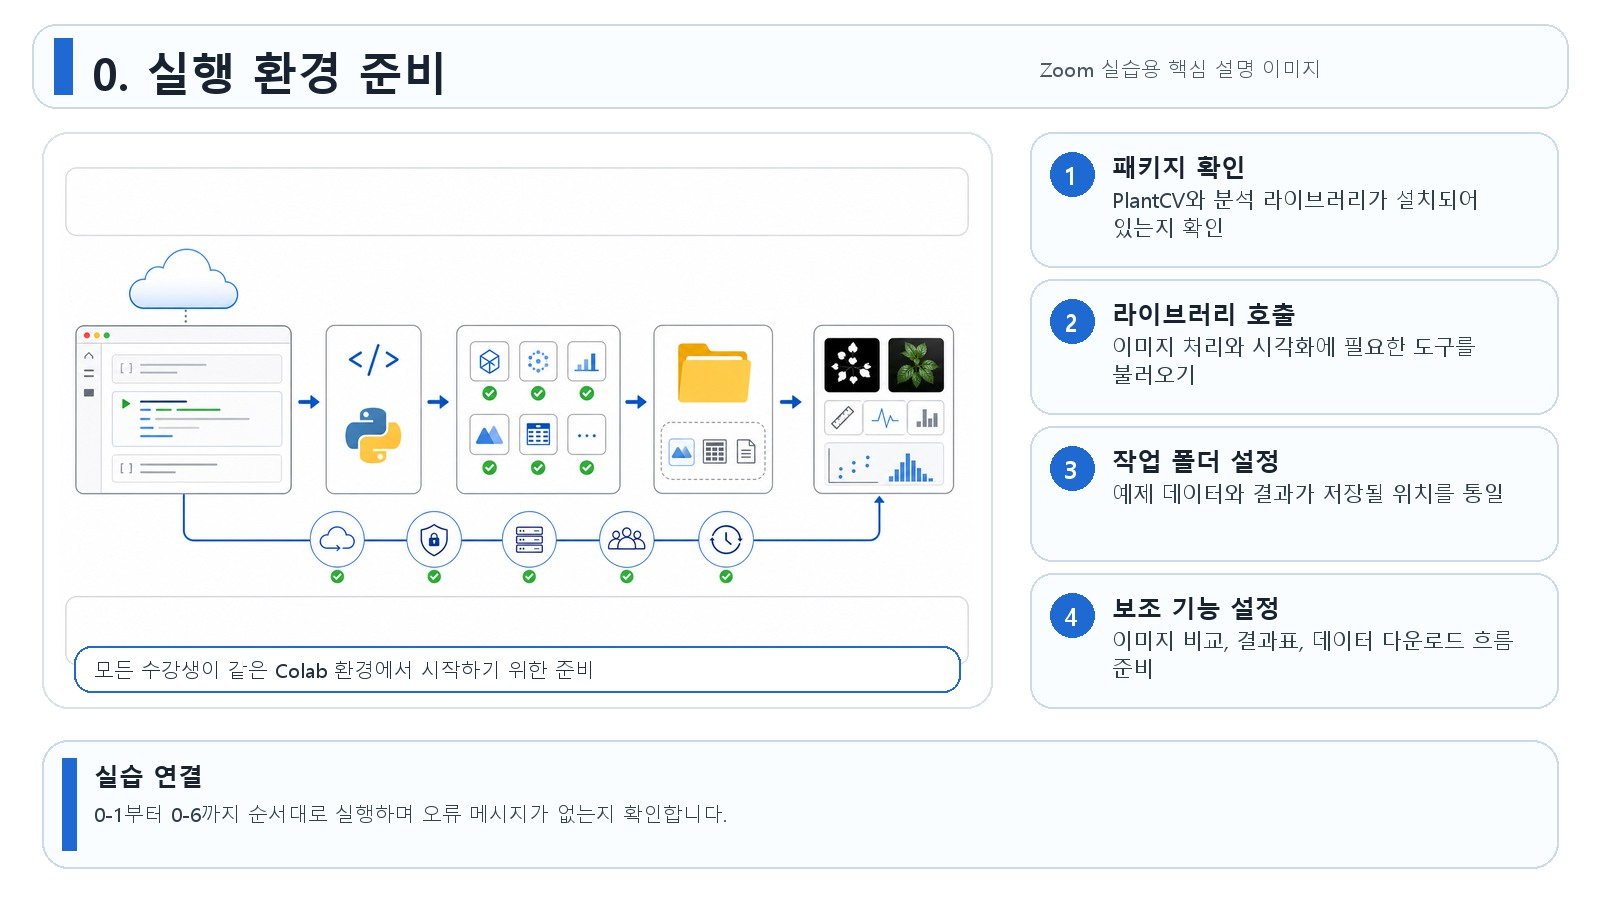</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 오늘 실습을 시작하기 전 필요한 준비 과정을 보여줍니다. 왼쪽의 노트북 화면은 Colab 실행 공간이고, 가운데의 패키지와 폴더 아이콘은 PlantCV 설치 확인, 라이브러리 호출, 작업 폴더 생성을 의미합니다. 오른쪽의 체크 표시는 모든 사람이 같은 출발점에서 실습을 시작하도록 환경을 맞추는 단계입니다.
>
> **강사 진행 포인트:** "아직 식물 이미지를 분석하는 단계가 아니라, 모든 수강생의 실행 환경을 동일하게 맞추는 단계입니다. 이 장의 셀은 결과 이미지보다 오류 메시지가 없는지 확인하는 것이 중요합니다."
>
> **실습 연결:** 아래 0-1부터 0-6까지는 패키지 확인, 작업 폴더 설정, 이미지 비교 출력, crop 보정, 결과표 정리, 예제 데이터 다운로드를 순서대로 준비합니다.

<details>
<summary><b>왜 환경 준비를 여러 셀로 나누나요?</b></summary>

Colab을 처음 쓰는 사람에게는 한 셀 안에서 설치, import, 이미지 출력 방식, 값 보정, 데이터 다운로드 설정이 한꺼번에 일어나면 흐름을 따라가기 어렵습니다. 그래서 이 장은 다음 순서로 나눕니다.

1. 필요한 패키지가 있는지 확인하고 없으면 설치합니다.
2. 사용할 라이브러리를 불러오고 작업 폴더를 만듭니다.
3. 원본 이미지와 마스크를 나란히 비교해서 볼 수 있게 합니다.
4. crop, 색공간 변환, 결과표 생성을 안전하게 반복할 수 있게 합니다.
5. GitHub 예제 데이터를 안정적으로 내려받고 재사용할 수 있게 합니다.

</details>


## 0-0. Colab/런타임 환경 진단

**이 셀에서 하는 일:** 현재 실행 환경, Python 버전, `git` 사용 가능 여부, GitHub/PyPI 접속 가능 여부를 먼저 확인합니다.

**왜 필요한가요:** 외부 교육에서는 PC, 브라우저, 네트워크 상태가 모두 다릅니다. 분석 코드 전에 환경 문제를 먼저 분리하면 교육 중 원인을 찾기 쉽습니다.


In [ ]:
#@title 00-0. Colab/런타임 환경 진단 { display-mode: "form" }
RUN_ENVIRONMENT_CHECK = True #@param {type:"boolean"}
CHECK_NETWORK = True #@param {type:"boolean"}

import os
import pathlib
import platform
import shutil
import subprocess
import sys
import time
import urllib.request

def check_url(url, timeout=10):
    try:
        request = urllib.request.Request(
            url,
            headers={"User-Agent": "RISE-phenotyping-practice/1.0"},
        )
        with urllib.request.urlopen(request, timeout=timeout) as response:
            return 200 <= getattr(response, "status", 200) < 400
    except Exception:
        return False

if RUN_ENVIRONMENT_CHECK:
    in_colab = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
    print("환경:", "Google Colab" if in_colab else "Local/Jupyter")
    print("Python:", sys.version.split()[0])
    print("플랫폼:", platform.platform())
    print("현재 폴더:", pathlib.Path.cwd())
    print("git 사용 가능:", "예" if shutil.which("git") else "아니오 - zip 다운로드 대체 경로를 사용합니다.")
    if CHECK_NETWORK:
        checks = {
            "GitHub": check_url("https://github.com", timeout=10),
            "GitHub raw": check_url("https://raw.githubusercontent.com", timeout=10),
            "PyPI": check_url("https://pypi.org/simple/plantcv/", timeout=10),
        }
        for name, ok in checks.items():
            print(f"{name} 연결:", "OK" if ok else "확인 필요")
        if not all(checks.values()):
            print("[주의] 네트워크가 불안정하면 패키지 설치나 예제 데이터 다운로드가 실패할 수 있습니다.")
            print("       잠시 후 다시 실행하거나, 강사용 네트워크/테더링 환경에서 먼저 0장을 완료하세요.")
    print("환경 진단 완료")
else:
    print("환경 진단을 건너뛰었습니다.")


## 0-1. 필수 패키지 확인 및 설치

**이 셀에서 하는 일:** `uv`를 우선 사용해 PlantCV와 분석/시각화 라이브러리를 빠르게 설치하고, 설치 후 버전 범위를 검증합니다. `uv` 설치나 실행이 실패하면 `pip`로 자동 대체합니다.

**배포용 보완점:** 단순히 `import` 가능 여부만 보지 않고, 교육 파일에서 검증한 버전 범위를 함께 확인합니다. 완전히 비어 있는 런타임에서도 이 셀 하나로 필요한 패키지를 준비하도록 구성했습니다.


In [ ]:
#@title 00-1. 필수 패키지 확인 및 설치 { display-mode: "form" }
INSTALL_DEPENDENCIES = True #@param {type:"boolean"}
INSTALL_BACKEND = "uv" #@param ["uv", "pip"]
QUIET_INSTALL = True #@param {type:"boolean"}
STOP_AFTER_INSTALL = False #@param {type:"boolean"}

import importlib
import importlib.util
import subprocess
import sys
from importlib import metadata as importlib_metadata

def run_command(cmd, label):
    print(label, " ".join(cmd))
    try:
        subprocess.check_call(cmd)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "패키지 설치 명령이 실패했습니다. 네트워크 연결을 확인한 뒤 이 셀을 다시 실행하세요. "
            f"실패한 명령: {' '.join(cmd)}"
        ) from exc

def module_available(module_name):
    importlib.invalidate_caches()
    return importlib.util.find_spec(module_name) is not None

def python_is_venv():
    return sys.prefix != getattr(sys, "base_prefix", sys.prefix)

def run_pip_install(package_specs, label="[PIP]"):
    cmd = [sys.executable, "-m", "pip", "install", "--upgrade"]
    if QUIET_INSTALL:
        cmd.append("-q")
    cmd.extend(package_specs)
    run_command(cmd, label)

def ensure_uv_available():
    if module_available("uv"):
        return True
    if not INSTALL_DEPENDENCIES:
        return False
    print("[BOOTSTRAP] uv가 없어 pip로 uv를 먼저 설치합니다.")
    try:
        run_pip_install(["uv>=0.5"], label="[BOOTSTRAP]")
        importlib.invalidate_caches()
        return module_available("uv")
    except RuntimeError as exc:
        print("[INFO] uv 설치가 실패하여 pip로 대체합니다.")
        print(str(exc).splitlines()[-1])
        return False

def run_uv_install(package_specs):
    if not ensure_uv_available():
        return False
    cmd = [sys.executable, "-m", "uv", "pip", "install", "--upgrade"]
    if python_is_venv():
        cmd.extend(["--python", sys.executable])
    else:
        cmd.append("--system")
    if QUIET_INSTALL:
        cmd.append("--quiet")
    cmd.extend(package_specs)
    try:
        run_command(cmd, "[UV]")
        return True
    except RuntimeError as exc:
        print("[INFO] uv 설치 명령이 실패하여 pip로 대체합니다.")
        print(str(exc).splitlines()[-1])
        return False

def install_packages(package_specs):
    if not package_specs:
        return
    if INSTALL_BACKEND == "uv" and run_uv_install(package_specs):
        return
    run_pip_install(package_specs, label="[PIP]")

if not module_available("packaging"):
    if not INSTALL_DEPENDENCIES:
        raise RuntimeError("버전 확인에 필요한 packaging 패키지가 없습니다. INSTALL_DEPENDENCIES를 True로 두고 다시 실행하세요.")
    install_packages(["packaging>=23"])

from packaging.specifiers import SpecifierSet
from packaging.version import InvalidVersion, Version

REQUIRED_PACKAGES = [
    {"module": "plantcv", "dist": "plantcv", "install": "plantcv==4.11.1", "version": "==4.11.1", "purpose": "PlantCV 분석"},
    {"module": "altair", "dist": "altair", "install": "altair>=5,<6", "version": ">=5,<6", "purpose": "히스토그램 시각화"},
    {"module": "IPython", "dist": "ipython", "install": "ipython>=8", "version": ">=8", "purpose": "노트북 출력"},
    {"module": "cv2", "dist": "opencv-python", "install": "opencv-python>=4.8", "version": ">=4.8", "purpose": "이미지 처리"},
    {"module": "skimage", "dist": "scikit-image", "install": "scikit-image>=0.22", "version": ">=0.22", "purpose": "PlantCV 의존 기능"},
    {"module": "sklearn", "dist": "scikit-learn", "install": "scikit-learn>=1.3", "version": ">=1.3", "purpose": "k-means 학습"},
    {"module": "matplotlib", "dist": "matplotlib", "install": "matplotlib>=3.7", "version": ">=3.7", "purpose": "이미지 출력"},
    {"module": "numpy", "dist": "numpy", "install": "numpy>=1.26", "version": ">=1.26", "purpose": "배열 계산"},
    {"module": "pandas", "dist": "pandas", "install": "pandas>=2.0", "version": ">=2.0", "purpose": "측정 결과표"},
]

def installed_version(dist_name):
    try:
        return importlib_metadata.version(dist_name)
    except importlib_metadata.PackageNotFoundError:
        return None

def satisfies(version_text, specifier_text):
    if version_text is None:
        return False
    try:
        return Version(version_text) in SpecifierSet(specifier_text)
    except InvalidVersion:
        return False

def package_status(package):
    module_ok = module_available(package["module"])
    version_text = installed_version(package["dist"])
    version_ok = satisfies(version_text, package["version"])
    return module_ok, version_text, version_ok

packages_to_install = []
for package in REQUIRED_PACKAGES:
    module_ok, version_text, version_ok = package_status(package)
    if module_ok and version_ok:
        print(f"[OK] {package['dist']} {version_text} - {package['purpose']}")
        continue
    reason = "없음" if not module_ok else f"버전 범위 불일치({version_text})"
    if not INSTALL_DEPENDENCIES:
        raise RuntimeError(
            f"{package['dist']} 패키지 확인 실패: {reason}. "
            "INSTALL_DEPENDENCIES를 True로 바꾸고 이 셀을 다시 실행하세요."
        )
    print(f"[NEED] {package['dist']} - {reason}")
    packages_to_install.append(package["install"])

if packages_to_install:
    install_packages(packages_to_install)

changed_packages = []
for package in REQUIRED_PACKAGES:
    module_ok, version_text, version_ok = package_status(package)
    if not (module_ok and version_ok):
        raise RuntimeError(
            f"{package['dist']} 설치 후에도 버전 확인이 실패했습니다. 현재 버전: {version_text}\n"
            "런타임을 다시 시작한 뒤 00-1 셀을 다시 실행하거나, 네트워크/패키지 저장소 접근을 확인하세요."
        )
    print(f"[OK] {package['dist']} {version_text} - 설치 확인")
    if package["install"] in packages_to_install:
        changed_packages.append(package["dist"])

if changed_packages:
    print("설치/업데이트된 패키지:", ", ".join(changed_packages))
    print("Colab에서 import 오류가 이어지면 메뉴에서 런타임 > 런타임 다시 시작 후 00-1부터 다시 실행하세요.")
    if STOP_AFTER_INSTALL:
        raise SystemExit("패키지 설치 후 중단했습니다. 런타임을 다시 시작한 뒤 00-1부터 재실행하세요.")

print("패키지 확인 완료")
print(f"사용한 설치 방식: {INSTALL_BACKEND} 우선, 실패 시 pip 대체")
print("다음 셀에서 라이브러리를 불러옵니다.")


## 0-2. 라이브러리 호출과 작업 폴더 설정

**이 셀에서 하는 일:** 실습에 사용할 Python 라이브러리를 불러오고, 예제 데이터가 저장될 작업 폴더를 정합니다.

**관찰 포인트:** Colab에서는 보통 `/content/rise_phenotyping_practice` 폴더가 만들어집니다. 로컬에서 실행하면 현재 노트북 폴더 아래에 같은 이름의 폴더가 생깁니다.


In [ ]:
#@title 00-2. 라이브러리 호출과 작업 폴더 설정 { display-mode: "form" }
import contextlib
import io
import os
import pathlib
import shutil
import subprocess
import sys
import urllib.request
import warnings
import zipfile
from importlib import metadata as importlib_metadata

from IPython.display import display
from plantcv import plantcv as pcv
from plantcv.learn import naive_bayes_multiclass, train_kmeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules
WORK_DIR = pathlib.Path("/content/rise_phenotyping_practice") if IN_COLAB else pathlib.Path.cwd() / "rise_phenotyping_practice"
DATA_DIR = WORK_DIR / "data"
RESULT_DIR = WORK_DIR / "results"
for folder in [WORK_DIR, DATA_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = False
warnings.filterwarnings("ignore", message="Glyph .* missing from font.*")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*")

DATA_MANIFEST = {
    "simple_rgb": {
        "commit": "6e9c35d736bc31782af3e760096c03f5dbe34049",
        "image": "img/1_B73_sand_C_2023-04-14_10_19_07.jpg",
    },
    "supervised": {
        "repo": "https://github.com/danforthcenter/plantcv-tutorial-supervised-ml.git",
        "commit": "d57501166da0218a388a0f23f681a0117bf1bf76",
        "required": ["img/wheat_rust1.png", "img/wheat_rust2.png", "example_data/pixel_values.txt"],
    },
    "unsupervised": {
        "repo": "https://github.com/danforthcenter/plantcv-tutorial-unsupervised-ml.git",
        "commit": "4a52eb64edbaa343cc86ab9793e61de28d1dcb5a",
        "required": ["img/10.9.1.230_pos-165-001-004_2019-11-01-10-05.jpg"],
    },
}

def require_vars(*names, hint=""):
    missing = [name for name in names if name not in globals()]
    if missing:
        detail = ", ".join(missing)
        message = f"필요한 선행 단계가 아직 실행되지 않았습니다: {detail}"
        if hint:
            message += f"\n먼저 실행할 셀: {hint}"
        raise RuntimeError(message)

def package_version(dist_name):
    try:
        return importlib_metadata.version(dist_name)
    except importlib_metadata.PackageNotFoundError:
        return "unknown"

def ensure_file_exists(path, description="파일"):
    path = pathlib.Path(path)
    if not path.exists() or path.stat().st_size == 0:
        raise RuntimeError(f"{description}을 찾을 수 없습니다: {path}")
    return path

def validate_rgb_image(image, description="이미지"):
    if image is None or getattr(image, "size", 0) == 0:
        raise RuntimeError(f"{description}을 읽지 못했습니다.")
    if getattr(image, "ndim", 0) != 3 or image.shape[2] != 3:
        raise RuntimeError(f"{description}은 RGB 3채널 이미지여야 합니다. 현재 shape: {getattr(image, 'shape', None)}")
    return image

print(f"작업 폴더: {WORK_DIR}")
print(f"데이터 폴더: {DATA_DIR}")
print(f"결과 폴더: {RESULT_DIR}")
print("주요 패키지 버전:")
for dist_name in ["plantcv", "numpy", "pandas", "matplotlib", "scikit-learn", "scikit-image", "opencv-python"]:
    print(f"- {dist_name}: {package_version(dist_name)}")
print("라이브러리 호출 완료")


## 0-3. 이미지 비교 출력

**이 셀에서 하는 일:** 원본 이미지, 마스크, 분석 결과를 한 줄에 나란히 비교해서 볼 수 있게 합니다.

**왜 필요한가요:** 표현체 분석은 숫자만 보는 것이 아니라, 매 단계에서 이미지가 어떻게 바뀌는지 확인해야 합니다.


In [ ]:
#@title 00-3. 이미지 비교 출력 { display-mode: "form" }
def show_grid(images, titles=None, cmaps=None, figsize=None):
    """여러 이미지를 한 줄로 비교해서 보여줍니다."""
    images = list(images)
    n = len(images)
    titles = list(titles or [""] * n)
    cmaps = list(cmaps or [None] * n)
    if len(titles) != n or len(cmaps) != n:
        raise ValueError("images, titles, cmaps의 길이가 같아야 합니다.")
    if figsize is None:
        figsize = (4.2 * n, 4.2)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, image, title, cmap in zip(axes, images, titles, cmaps):
        if image is None:
            ax.axis("off")
            continue
        if cmap is None and getattr(image, "ndim", 0) == 2:
            cmap = "gray"
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("이미지 비교 출력 설정 완료")


## 0-4. 이미지 범위 보정 및 채널 변환

**이 셀에서 하는 일:** crop 값이 이미지 범위를 벗어나지 않게 보정하고, 선택한 색공간 채널을 회색조 이미지로 바꿀 수 있게 합니다.

**관찰 포인트:** 나중에 슬라이더 값을 바꾸다가 범위를 조금 넘어도 노트북이 멈추지 않도록 안전장치를 둔 부분입니다.


In [ ]:
#@title 00-4. 이미지 범위 보정 및 채널 변환 { display-mode: "form" }
def bounded_crop(image, x, y, w, h):
    """잘못된 crop 값이 들어와도 이미지 범위 안으로 보정합니다."""
    img_h, img_w = image.shape[:2]
    x = int(np.clip(x, 0, max(img_w - 1, 0)))
    y = int(np.clip(y, 0, max(img_h - 1, 0)))
    w = int(np.clip(w, 1, img_w - x))
    h = int(np.clip(h, 1, img_h - y))
    return pcv.crop(img=image, x=x, y=y, h=h, w=w), {"x": x, "y": y, "w": w, "h": h}

def channel_from_choice(rgb_image, choice):
    """Form에서 고른 색공간 채널을 회색조 이미지로 변환합니다."""
    space, channel = choice.split("-")
    channel = channel.lower()
    if space == "LAB":
        return pcv.rgb2gray_lab(rgb_img=rgb_image, channel=channel)
    if space == "HSV":
        return pcv.rgb2gray_hsv(rgb_img=rgb_image, channel=channel)
    if space == "CMYK":
        return pcv.rgb2gray_cmyk(rgb_img=rgb_image, channel=channel)
    raise ValueError(f"Unknown channel choice: {choice}")

print("이미지 자르기와 채널 변환 설정 완료")


## 0-5. 측정 결과표 정리

**이 셀에서 하는 일:** PlantCV가 저장한 측정 결과에서 필요한 값을 꺼내 표로 정리할 수 있게 합니다.

**왜 필요한가요:** 교육에서는 `pcv.outputs.observations` 같은 내부 구조보다, 면적과 둘레가 표로 정리되어 보이는 편이 이해하기 쉽습니다.


In [ ]:
#@title 00-5. 측정 결과표 정리 { display-mode: "form" }
def clear_pcv_outputs():
    """이전 분석 결과가 섞이지 않도록 PlantCV 출력 저장소를 비웁니다."""
    try:
        pcv.outputs.clear()
    except Exception:
        try:
            pcv.outputs.observations.clear()
        except Exception:
            pass

def obs_value(observation, key):
    item = observation.get(key, {})
    return item.get("value", None)

def size_table_from_outputs(label_prefix=None, max_rows=None, min_area_px=0, sort_by_area=False):
    rows = []
    for label, observation in pcv.outputs.observations.items():
        if label_prefix and not label.startswith(label_prefix):
            continue
        rows.append(
            {
                "object": label,
                "area_px": obs_value(observation, "area"),
                "convex_hull_area_px": obs_value(observation, "convex_hull_area"),
                "solidity": obs_value(observation, "solidity"),
                "perimeter_px": obs_value(observation, "perimeter"),
                "height_px": obs_value(observation, "height"),
                "width_px": obs_value(observation, "width"),
            }
        )
    table = pd.DataFrame(rows)
    if table.empty:
        print("[주의] 측정 결과가 비어 있습니다. 앞 단계 마스크와 ROI를 확인하세요.")
        return table
    if min_area_px:
        table = table[table["area_px"].fillna(0) >= min_area_px]
    if sort_by_area and "area_px" in table:
        table = table.sort_values("area_px", ascending=False)
    if max_rows is not None:
        table = table.head(max_rows)
    return table.reset_index(drop=True)

def mask_summary(mask, name="mask"):
    arr = np.asarray(mask)
    if arr.size == 0:
        print(f"{name}: 비어 있는 배열입니다.")
        return 0.0
    if arr.ndim == 3:
        selected = int(np.count_nonzero(np.any(arr > 0, axis=-1)))
        total = int(arr.shape[0] * arr.shape[1])
    else:
        selected = int(np.count_nonzero(arr))
        total = int(arr.size)
    pct = 100 * selected / max(total, 1)
    print(f"{name}: 선택 픽셀 {selected:,} / {total:,} ({pct:.2f}%)")
    if pct < 0.05:
        print("[주의] 선택된 영역이 거의 없습니다. threshold, 군집 번호, ROI 값을 확인하세요.")
    elif pct > 95:
        print("[주의] 거의 전체 이미지가 선택되었습니다. 배경까지 포함되었을 가능성이 큽니다.")
    return pct

print("측정 결과표와 마스크 요약 설정 완료")


## 0-6. 예제 데이터 다운로드

**이 셀에서 하는 일:** 실습에 사용할 PlantCV 공개 예제 데이터를 작업 폴더에 준비합니다. `git clone`이 가능하면 빠르게 받고, 실패하면 zip 다운로드로 대체합니다.

**배포용 보완점:** 기존 폴더가 있더라도 필수 파일이 없으면 불완전한 캐시로 판단하고 다시 다운로드합니다. 원본 RGB 이미지도 URL에서 바로 읽지 않고 작업 폴더에 저장한 뒤 읽습니다.

**출처:** PlantCV tutorial repositories and example images on GitHub. 첫 실행에는 GitHub 접속이 필요합니다.


In [ ]:
#@title 00-6. 예제 데이터 다운로드 { display-mode: "form" }
DOWNLOAD_TIMEOUT_SECONDS = 90 #@param {type:"slider", min:30, max:180, step:30}
DOWNLOAD_RETRIES = 3 #@param {type:"slider", min:1, max:5, step:1}
OFFLINE_ASSET_ZIP = "rise_phenotyping_assets.zip" #@param {type:"string"}
REMOTE_ASSET_ZIP_URL = "https://raw.githubusercontent.com/Dosin-Lee/260709_RISE_phenome/main/assets/rise_phenotyping_assets.zip" #@param {type:"string"}

def parse_int_list(text, minimum=0, maximum=None, default=None):
    values = []
    for part in str(text).replace(";", ",").split(","):
        part = part.strip()
        if not part:
            continue
        try:
            value = int(part)
        except ValueError:
            continue
        if value < minimum:
            continue
        if maximum is not None and value > maximum:
            continue
        values.append(value)
    if not values and default is not None:
        values = list(default)
    return values

def safe_remove_tree(path):
    path = pathlib.Path(path)
    if not path.exists():
        return
    resolved = path.resolve()
    work = WORK_DIR.resolve()
    if str(resolved).startswith(str(work)):
        shutil.rmtree(resolved, ignore_errors=True)
    else:
        raise RuntimeError(f"작업 폴더 밖의 경로는 자동 삭제하지 않습니다: {resolved}")

def required_paths_exist(base_dir, required_paths):
    base_dir = pathlib.Path(base_dir)
    return all((base_dir / rel).exists() and (base_dir / rel).stat().st_size > 0 for rel in required_paths)

def find_offline_zip():
    candidates = [
        pathlib.Path.cwd() / OFFLINE_ASSET_ZIP,
        WORK_DIR / OFFLINE_ASSET_ZIP,
        WORK_DIR.parent / OFFLINE_ASSET_ZIP,
        pathlib.Path("/content") / OFFLINE_ASSET_ZIP,
    ]
    for candidate in candidates:
        if candidate.exists() and candidate.stat().st_size > 0:
            return candidate
    return None

def safe_extract_zip_file(zip_path, target_dir):
    zip_path = pathlib.Path(zip_path)
    target_dir = pathlib.Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    target_root = target_dir.resolve()
    with zipfile.ZipFile(zip_path) as zf:
        for member in zf.infolist():
            member_path = (target_dir / member.filename).resolve()
            if not str(member_path).startswith(str(target_root)):
                raise RuntimeError(f"Zip 파일 안에 안전하지 않은 경로가 있습니다: {member.filename}")
        zf.extractall(target_dir)

def try_offline_assets(target_dir, required_paths):
    offline_zip = find_offline_zip()
    if offline_zip is None:
        return False
    print(f"[OFFLINE] 자산 zip 확인: {offline_zip}")
    safe_extract_zip_file(offline_zip, WORK_DIR)
    if required_paths_exist(target_dir, required_paths):
        print(f"[OK] 오프라인 자산에서 데이터 준비: {target_dir}")
        return True
    return False

def download_file(url, destination, description="파일", retries=None):
    destination = pathlib.Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size > 0:
        print(f"[OK] 기존 {description} 사용: {destination}")
        return destination
    offline_zip = find_offline_zip()
    if offline_zip is not None:
        print(f"[OFFLINE] 자산 zip 확인: {offline_zip}")
        safe_extract_zip_file(offline_zip, WORK_DIR)
        if destination.exists() and destination.stat().st_size > 0:
            print(f"[OK] 오프라인 자산에서 {description} 준비: {destination}")
            return destination
    retries = DOWNLOAD_RETRIES if retries is None else retries
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            print(f"[DOWNLOAD] {description} ({attempt}/{retries})")
            request = urllib.request.Request(
                url,
                headers={"User-Agent": "RISE-phenotyping-practice/1.0"},
            )
            with urllib.request.urlopen(request, timeout=DOWNLOAD_TIMEOUT_SECONDS) as response:
                payload = response.read()
            if not payload:
                raise RuntimeError("다운로드한 파일이 비어 있습니다.")
            destination.write_bytes(payload)
            print(f"[OK] 저장 완료: {destination}")
            return destination
        except Exception as exc:
            last_error = exc
            if destination.exists():
                destination.unlink()
            print(f"[RETRY] {description} 다운로드 실패: {exc}")
    raise RuntimeError(
        f"{description} 다운로드에 실패했습니다. 네트워크를 확인한 뒤 이 셀을 다시 실행하세요: {url}\n"
        f"기관망에서 GitHub가 막혀 있다면 강사가 제공한 {OFFLINE_ASSET_ZIP}을 노트북과 같은 위치에 올려두세요."
    ) from last_error

def safe_extract_payload(payload, target_dir):
    target_dir = pathlib.Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(io.BytesIO(payload)) as zf:
        target_root = target_dir.resolve()
        for member in zf.infolist():
            member_path = (target_dir / member.filename).resolve()
            if not str(member_path).startswith(str(target_root)):
                raise RuntimeError(f"Zip 파일 안에 안전하지 않은 경로가 있습니다: {member.filename}")
        zf.extractall(target_dir)

def ensure_github_repo(repo_url, target_dir, required_paths=None, ref=None):
    """GitHub 예제 데이터를 고정 commit 기준으로 내려받거나 검증된 기존 폴더를 재사용합니다."""
    target_dir = pathlib.Path(target_dir)
    required_paths = required_paths or []
    if target_dir.exists():
        if required_paths_exist(target_dir, required_paths):
            print(f"[OK] 검증된 기존 데이터 사용: {target_dir}")
            return target_dir
        print(f"[INFO] 기존 데이터가 불완전하여 다시 준비합니다: {target_dir}")
        safe_remove_tree(target_dir)
    target_dir.parent.mkdir(parents=True, exist_ok=True)

    if try_offline_assets(target_dir, required_paths):
        return target_dir

    owner_repo = repo_url.rstrip("/").removesuffix(".git").split("github.com/")[-1]
    ref = ref or "main"

    try:
        subprocess.run(["git", "clone", "--depth", "1", repo_url, str(target_dir)], check=True)
        if ref not in ["main", "master"]:
            subprocess.run(["git", "-C", str(target_dir), "fetch", "--depth", "1", "origin", ref], check=True)
            subprocess.run(["git", "-C", str(target_dir), "checkout", "--detach", ref], check=True)
        if required_paths_exist(target_dir, required_paths):
            print(f"[OK] Cloned: {repo_url} @ {ref}")
            return target_dir
        print("[INFO] git clone 결과에 필수 파일이 없어 zip 다운로드를 시도합니다.")
        safe_remove_tree(target_dir)
    except Exception as git_error:
        safe_remove_tree(target_dir)
        print("[INFO] git clone 실패, zip 다운로드를 시도합니다.")
        print(str(git_error).splitlines()[-1])

    zip_url = f"https://github.com/{owner_repo}/archive/{ref}.zip"
    last_error = None
    for attempt in range(1, DOWNLOAD_RETRIES + 1):
        temp_extract = target_dir.parent / f"{target_dir.name}_zip_extract"
        try:
            print(f"[DOWNLOAD] {zip_url} ({attempt}/{DOWNLOAD_RETRIES})")
            request = urllib.request.Request(
                zip_url,
                headers={"User-Agent": "RISE-phenotyping-practice/1.0"},
            )
            with urllib.request.urlopen(request, timeout=DOWNLOAD_TIMEOUT_SECONDS) as response:
                payload = response.read()
            safe_remove_tree(temp_extract)
            safe_extract_payload(payload, temp_extract)
            extracted_roots = [p for p in temp_extract.iterdir() if p.is_dir()]
            if not extracted_roots:
                raise RuntimeError("Zip archive did not contain a directory.")
            shutil.move(str(extracted_roots[0]), str(target_dir))
            safe_remove_tree(temp_extract)
            if not required_paths_exist(target_dir, required_paths):
                raise RuntimeError("다운로드 후에도 필수 파일이 없습니다.")
            print(f"[OK] Downloaded: {repo_url} @ {ref}")
            return target_dir
        except Exception as exc:
            last_error = exc
            safe_remove_tree(temp_extract)
            safe_remove_tree(target_dir)
            print(f"[RETRY] zip 다운로드 실패: {exc}")
    raise RuntimeError(
        f"예제 데이터를 준비하지 못했습니다. 네트워크 상태를 확인하고 이 셀을 다시 실행하세요: {repo_url}\n"
        f"기관망에서 GitHub가 막혀 있다면 강사가 제공한 {OFFLINE_ASSET_ZIP}을 노트북과 같은 위치에 올려두세요."
    ) from last_error

def read_plantcv_image(path, description="이미지"):
    path = ensure_file_exists(path, description)
    image, image_path, image_name = pcv.readimage(filename=str(path))
    validate_rgb_image(image, description)
    return image, image_path, image_name

@contextlib.contextmanager
def working_directory(path):
    old = pathlib.Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(old)

print("예제 데이터 다운로드와 검증 설정 완료")
print("이제 아래 실습 셀을 순서대로 실행하세요.")


## 데이터와 이미지 출처

이 실습의 분석 예제 데이터는 Danforth Center PlantCV 공개 튜토리얼 자료를 사용합니다. 교육 재현성을 위해 2026-06-29에 확인한 commit을 노트북 안에 고정했습니다.

- `plantcv-tutorial-simple-rgb-workflow`: `6e9c35d736bc31782af3e760096c03f5dbe34049`
- `plantcv-tutorial-supervised-ml`: `d57501166da0218a388a0f23f681a0117bf1bf76`
- `plantcv-tutorial-unsupervised-ml`: `4a52eb64edbaa343cc86ab9793e61de28d1dcb5a`
- 예제 데이터 출처: Danforth Center PlantCV tutorials, CC BY 4.0
- 노트북 내 설명 이미지는 교육용으로 생성/편집한 시각 자료이며, 분석용 원본 데이터가 아닙니다.


# 1. RGB 이미지 로드와 기본 구조 확인

<p>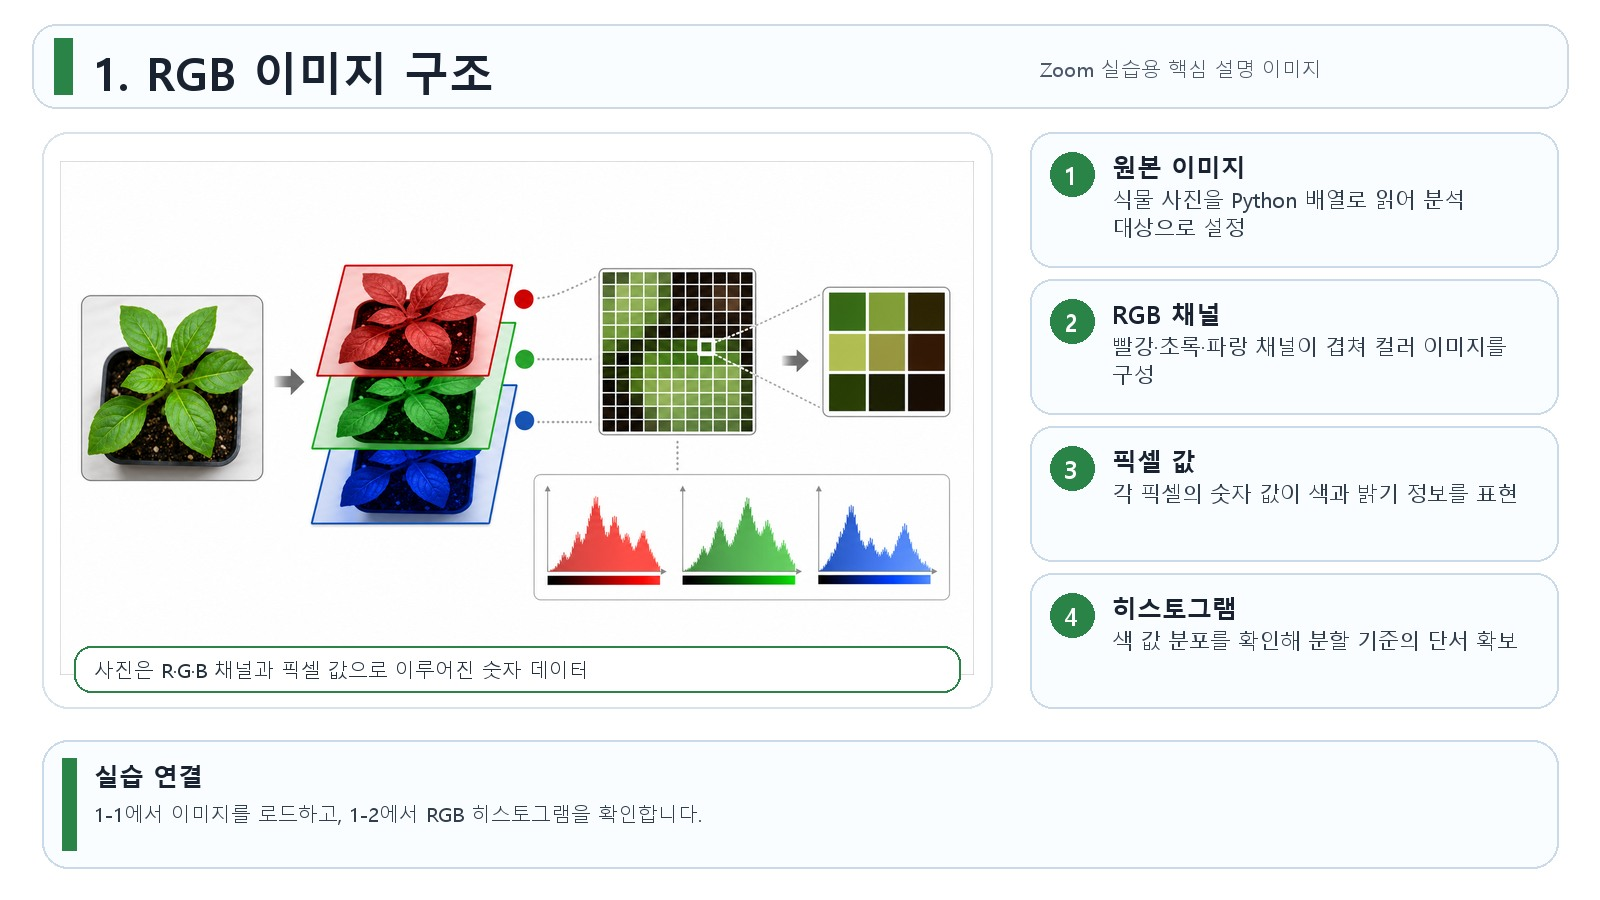</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 RGB 이미지가 단순한 사진이 아니라 숫자 배열이라는 점을 설명합니다. 하나의 식물 이미지는 R, G, B 세 채널로 나뉘고, 각 채널은 픽셀 단위의 밝기 값을 가집니다. 오른쪽의 히스토그램은 이미지 안에 어떤 색 값이 많이 분포하는지 보여주는 요약 그래프입니다.
>
> **강사 진행 포인트:** "표현체 분석에서 이미지는 사람이 보는 사진이면서 동시에 컴퓨터가 처리하는 숫자 데이터입니다. 오늘 실습은 이 숫자 데이터에서 식물과 배경을 구분하는 과정입니다."
>
> **실습 연결:** 1-1에서는 이미지를 불러오고 shape를 확인합니다. 1-2에서는 RGB 히스토그램을 보며 색 값 분포가 분할의 단서가 된다는 점을 확인합니다.

PPT에서 여러 촬영 장비와 사례를 봤지만, 이번 실습은 가장 접근성이 좋은 **RGB 이미지**를 사용합니다. RGB 이미지는 각 픽셀이 빨강(R), 초록(G), 파랑(B) 값으로 구성된 3차원 배열입니다.

<details>
<summary><b>처음 보는 용어 펼쳐보기</b></summary>

- **픽셀:** 이미지를 이루는 가장 작은 점입니다.
- **채널:** RGB 이미지에서는 R, G, B 세 장의 숫자판이 겹쳐 있다고 생각하면 됩니다.
- **히스토그램:** 이미지 안에 어떤 밝기나 색 값이 얼마나 많은지 보여주는 그래프입니다.
- **마스크:** 관심 있는 영역은 흰색 또는 1, 나머지는 검은색 또는 0으로 표시한 이미지입니다.

</details>


## 1-1. 원본 RGB 이미지 로드

**이 셀에서 하는 일:** 인터넷에 있는 예제 이미지를 읽어 `img` 변수에 저장합니다.

**관찰 포인트:** 출력되는 `shape`에서 첫 번째 숫자는 세로, 두 번째 숫자는 가로, 세 번째 숫자는 RGB 채널 수입니다.


In [ ]:
#@title 01-1. 원본 RGB 이미지 로드 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("pcv", "WORK_DIR", "DATA_DIR", "DATA_MANIFEST", "download_file", "read_plantcv_image", "show_grid", hint="00-1부터 00-6까지")

sample_url = "https://raw.githubusercontent.com/danforthcenter/plantcv-tutorial-simple-rgb-workflow/6e9c35d736bc31782af3e760096c03f5dbe34049/img/1_B73_sand_C_2023-04-14_10_19_07.jpg" #@param {type:"string"}

sample_image_path = download_file(
    sample_url,
    DATA_DIR / "simple-rgb-workflow" / "1_B73_sand_C_2023-04-14_10_19_07.jpg",
    description="RGB 예제 이미지",
)
img, path, filename = read_plantcv_image(sample_image_path, description="RGB 예제 이미지")

print(f"이미지 배열 shape: {img.shape}")
print("해석: (세로 픽셀 수, 가로 픽셀 수, RGB 채널 수)")
show_grid([img], ["원본 RGB 이미지"], figsize=(6, 4.5))


## 1-2. RGB 히스토그램 확인

**이 셀에서 하는 일:** 원본 이미지의 색 값 분포를 히스토그램으로 봅니다.

**관찰 포인트:** 식물, 흙, 배경이 서로 다른 색 분포를 만들기 때문에 이후 분할의 단서가 됩니다.


In [ ]:
#@title 01-2. RGB 히스토그램 확인 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('img', 'pcv', 'display', hint='01-1. 원본 RGB 이미지 로드')

histogram_bins = 30 #@param {type:"slider", min:10, max:100, step:5}

display(pcv.visualize.histogram(img=img, bins=histogram_bins))


# 2. 관심 영역 Crop과 색공간 확인

<p>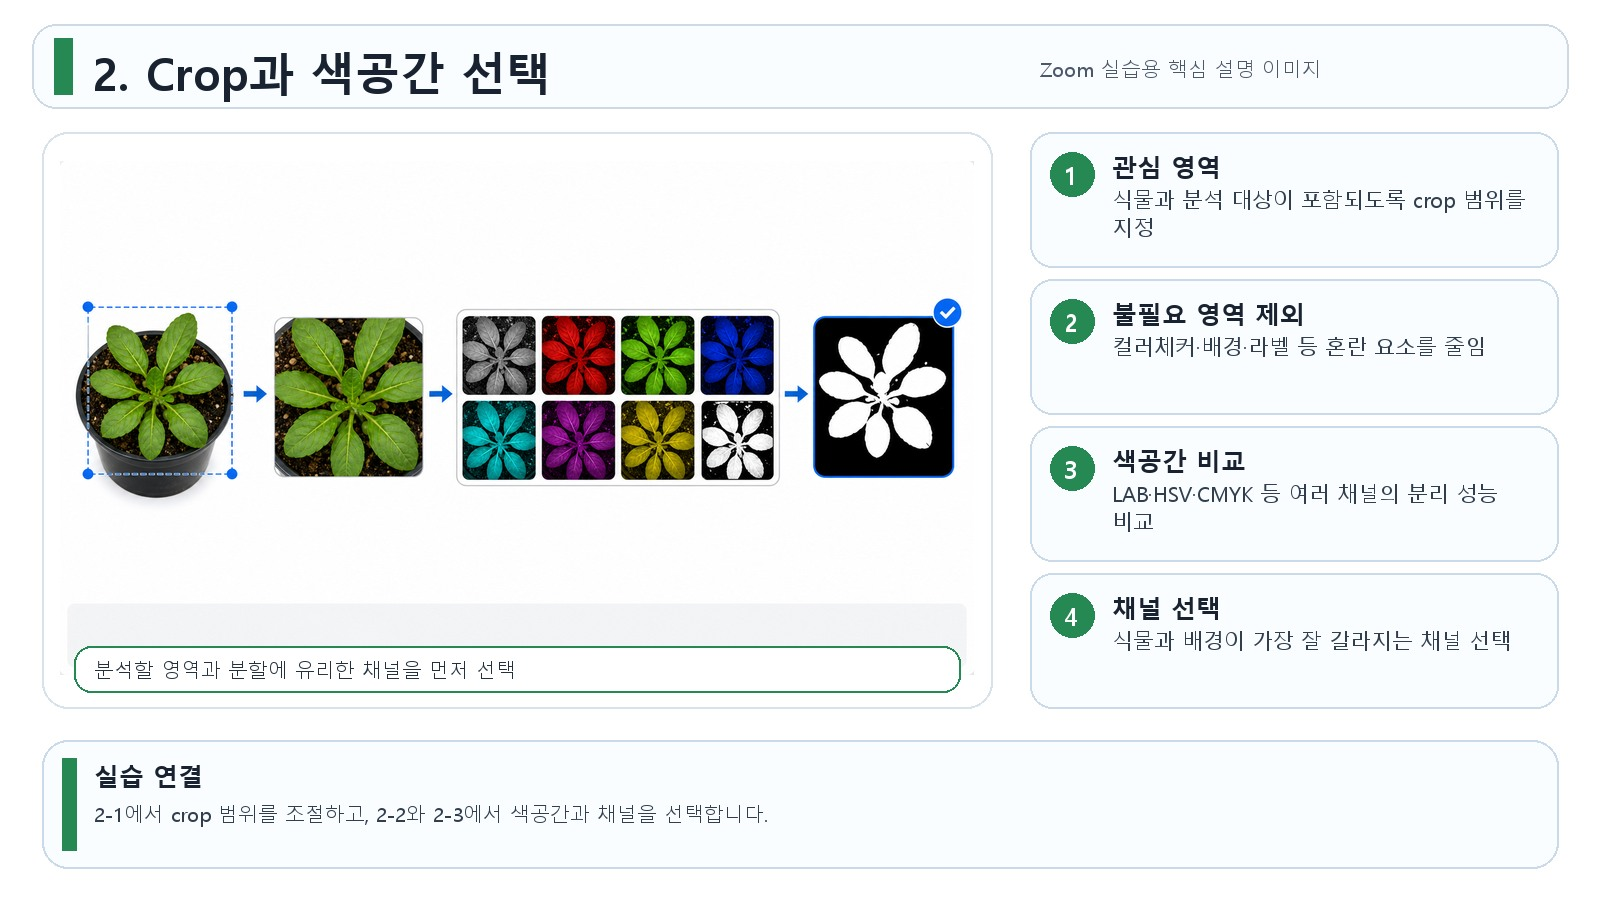</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 전체 이미지에서 분석에 필요한 영역만 잘라내고, 여러 색공간 채널을 비교하는 과정을 보여줍니다. Crop은 불필요한 배경이나 장비 영역을 줄이는 단계이고, 색공간 비교는 식물과 배경이 가장 잘 분리되는 채널을 찾는 단계입니다.
>
> **강사 진행 포인트:** "좋은 분석은 좋은 모델만으로 되는 것이 아니라, 분석할 영역을 적절히 정하고 식물이 잘 보이는 채널을 고르는 전처리에서 시작됩니다."
>
> **실습 연결:** 2-1에서 crop 범위를 조절하고, 2-2에서 색공간을 비교한 뒤, 2-3에서 이후 threshold에 사용할 채널을 선택합니다.

실제 표현체 분석에서는 촬영 이미지 안에 식물, 화분, 배경, 컬러체커, 라벨 등이 함께 들어갑니다. 분석 대상이 아닌 영역을 줄이면 이후 분할이 쉬워집니다.

<details>
<summary><b>왜 색공간을 바꾸나요?</b></summary>

RGB만으로도 분석할 수 있지만, 식물과 배경이 더 잘 갈라지는 채널이 따로 있을 수 있습니다. 예를 들어 LAB 색공간의 `b` 채널은 노랑-파랑 방향의 색 차이를 나타내므로, 녹색 식물과 흙 배경을 구분하는 데 도움이 되는 경우가 많습니다.

</details>


## 2-1. 관심 영역 Crop

**이 셀에서 하는 일:** 전체 이미지 중 분석에 사용할 영역만 잘라 `crop_img` 변수에 저장합니다.

**바꿔볼 값:** `crop_x`, `crop_y`, `crop_w`, `crop_h`를 조절해 식물과 컬러체커가 어떻게 포함되는지 확인하세요.


In [ ]:
#@title 02-1. 관심 영역 Crop { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('img', 'bounded_crop', 'show_grid', hint='01-1. 원본 RGB 이미지 로드')

crop_x = 1500 #@param {type:"slider", min:0, max:4500, step:50}
crop_y = 0 #@param {type:"slider", min:0, max:3400, step:50}
crop_w = 2500 #@param {type:"slider", min:300, max:4500, step:50}
crop_h = 2900 #@param {type:"slider", min:300, max:3400, step:50}

crop_img, crop_info = bounded_crop(img, crop_x, crop_y, crop_w, crop_h)

print("적용된 crop 값:", crop_info)
print(f"crop 이미지 shape: {crop_img.shape}")
show_grid([img, crop_img], ["Original", "Cropped region"], figsize=(10, 4.5))


## 2-2. 색공간 비교

**이 셀에서 하는 일:** RGB 이미지를 LAB, HSV, CMYK 등 여러 색공간 채널로 변환해 한 번에 보여줍니다.

**관찰 포인트:** 식물과 배경이 가장 잘 구분되어 보이는 채널을 찾아보세요. 이 실습의 기본값은 `LAB-b`입니다.


In [ ]:
#@title 02-2. 색공간 비교 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('crop_img', 'pcv', 'show_grid', hint='02-1. 관심 영역 Crop')

colorspace_img = pcv.visualize.colorspaces(rgb_img=crop_img)
show_grid([colorspace_img], ["Color space overview"], figsize=(10, 7))


## 2-3. 분석 채널 선택

**이 셀에서 하는 일:** 선택한 색공간 채널을 `channel_img` 변수에 저장합니다.

**바꿔볼 값:** `channel_choice`를 바꿔보고, 히스토그램 모양이 어떻게 달라지는지 확인하세요.


In [ ]:
#@title 02-3. 분석 채널 선택 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('crop_img', 'channel_from_choice', 'pcv', 'display', 'show_grid', hint='02-1. 관심 영역 Crop')

channel_choice = "LAB-b" #@param ["LAB-l", "LAB-a", "LAB-b", "HSV-h", "HSV-s", "HSV-v", "CMYK-c", "CMYK-m", "CMYK-y", "CMYK-k"]
show_channel_histogram = True #@param {type:"boolean"}
channel_histogram_bins = 30 #@param {type:"slider", min:10, max:100, step:5}

channel_img = channel_from_choice(crop_img, channel_choice)
print(f"선택한 채널: {channel_choice}")
show_grid([crop_img, channel_img], ["Cropped RGB", channel_choice], figsize=(9, 4.2))

if show_channel_histogram:
    display(pcv.visualize.histogram(img=channel_img, bins=channel_histogram_bins))


# 3. 전통적 방법: 기준값 기반 객체 분할

<p>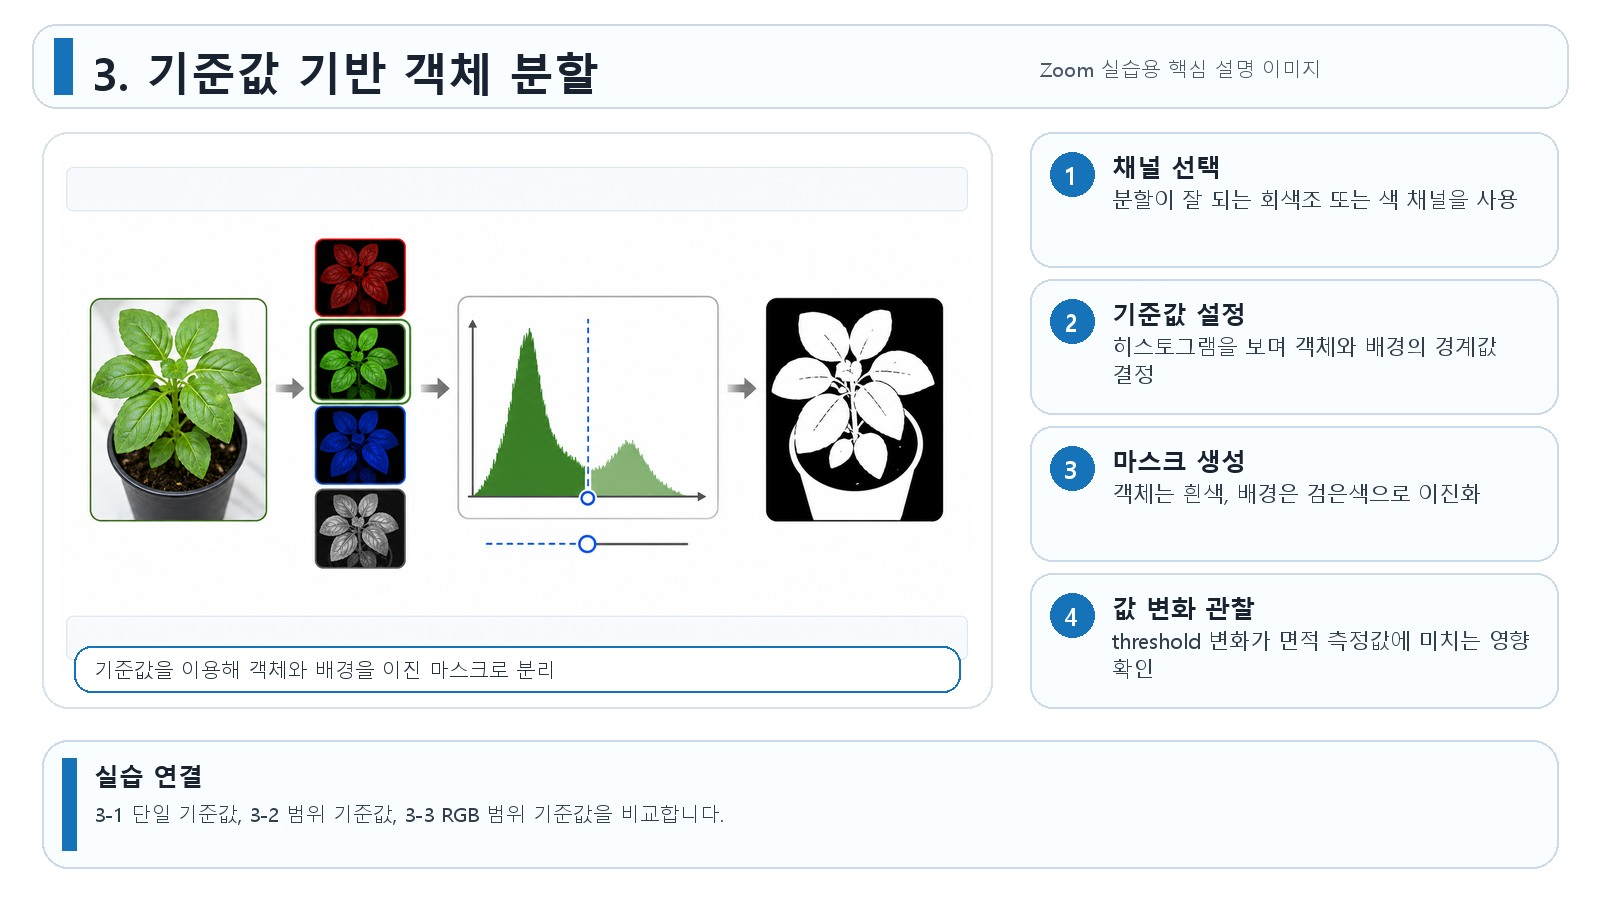</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 기준값 기반 분할의 핵심 흐름을 보여줍니다. 원본 이미지에서 특정 색공간 채널을 선택하고, 히스토그램에서 기준값을 정한 뒤, 기준보다 밝거나 어두운 픽셀을 흰색 마스크로 분리합니다.
>
> **강사 진행 포인트:** "threshold는 가장 단순하지만 가장 직관적인 객체 분할 방법입니다. 슬라이더 값을 조금만 바꿔도 마스크가 달라지므로, 분할 결과가 형질 측정값에 직접 영향을 준다는 점을 강조해 주세요."
>
> **실습 연결:** 3-1은 단일 기준값, 3-2는 범위 기준값, 3-3은 RGB 세 채널 범위를 이용한 마스크 생성을 비교합니다.

기준값(threshold)은 특정 색 또는 밝기 값보다 큰 픽셀을 객체로 볼지, 작은 픽셀을 객체로 볼지 정하는 가장 기본적인 분할 방법입니다. 오늘은 먼저 단일 채널에서 시작해 보고, 그다음 RGB 범위 기준도 비교합니다.

<details>
<summary><b>좋은 기준값을 찾는 감각</b></summary>

- 히스토그램에서 배경과 객체가 두 덩어리로 나뉘면 기준값을 잡기 쉽습니다.
- 기준값이 너무 낮으면 배경까지 객체에 포함됩니다.
- 기준값이 너무 높으면 실제 식물 일부가 빠질 수 있습니다.
- 촬영 조명과 배경이 바뀌면 같은 기준값이 항상 맞지는 않습니다.

</details>


## 3-1. 단일 기준값 이진 마스크 생성

**이 셀에서 하는 일:** 선택한 채널에서 기준값보다 밝거나 어두운 픽셀을 객체로 분리합니다.

**바꿔볼 값:** `threshold_value`를 움직이면 배경이 포함되거나 식물이 빠지는 경계가 보입니다.


In [ ]:
#@title 03-1. 단일 기준값 이진 마스크 생성 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('channel_img', 'pcv', 'show_grid', 'mask_summary', hint='02-3. 분석 채널 선택')

threshold_value = 130 #@param {type:"slider", min:0, max:255, step:1}
object_type = "light" #@param ["light", "dark"]

thresh_mask = pcv.threshold.binary(
    gray_img=channel_img,
    threshold=threshold_value,
    object_type=object_type,
)

print(f"threshold={threshold_value}, object_type={object_type}")
mask_summary(thresh_mask, "단일 기준값 마스크")
show_grid([channel_img, thresh_mask], [channel_choice, "Binary mask"], figsize=(8.5, 4))


## 3-2. 범위 기준값 마스크 생성

**이 셀에서 하는 일:** 하나의 기준값이 아니라 `lower`와 `upper` 사이에 들어오는 픽셀만 남깁니다.

**관찰 포인트:** 단일 threshold보다 더 좁은 색 범위를 선택할 수 있지만, 범위를 너무 좁히면 실제 객체가 빠질 수 있습니다.


In [ ]:
#@title 03-2. 범위 기준값 마스크 생성 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('channel_img', 'pcv', 'show_grid', 'mask_summary', hint='02-3. 분석 채널 선택')

gray_lower = 131 #@param {type:"slider", min:0, max:255, step:1}
gray_upper = 180 #@param {type:"slider", min:0, max:255, step:1}

gray_lower, gray_upper = sorted([gray_lower, gray_upper])
range_result = pcv.threshold.custom_range(
    img=channel_img,
    lower_thresh=[gray_lower],
    upper_thresh=[gray_upper],
    channel="gray",
)
range_mask = range_result[0] if isinstance(range_result, tuple) else range_result

print(f"Gray range: {gray_lower} to {gray_upper}")
mask_summary(range_mask, "범위 기준값 마스크")
show_grid([channel_img, range_mask], [channel_choice, "Gray range mask"], figsize=(8.5, 4))


## 3-3. RGB 범위 기준값 마스크 생성

**이 셀에서 하는 일:** R, G, B 세 채널의 범위를 동시에 지정해서 마스크를 만듭니다.

**바꿔볼 값:** 식물은 초록 계열이므로 `G` 범위가 넓게 들어가는지, 배경이 섞이지 않는지 확인해 보세요.


In [ ]:
#@title 03-3. RGB 범위 기준값 마스크 생성 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('crop_img', 'pcv', 'show_grid', 'mask_summary', hint='02-1. 관심 영역 Crop')

r_min = 0 #@param {type:"slider", min:0, max:255, step:5}
r_max = 100 #@param {type:"slider", min:0, max:255, step:5}
g_min = 50 #@param {type:"slider", min:0, max:255, step:5}
g_max = 200 #@param {type:"slider", min:0, max:255, step:5}
b_min = 0 #@param {type:"slider", min:0, max:255, step:5}
b_max = 150 #@param {type:"slider", min:0, max:255, step:5}

r_min, r_max = sorted([r_min, r_max])
g_min, g_max = sorted([g_min, g_max])
b_min, b_max = sorted([b_min, b_max])

rgb_mask, _ = pcv.threshold.custom_range(
    img=crop_img,
    lower_thresh=[r_min, g_min, b_min],
    upper_thresh=[r_max, g_max, b_max],
    channel="rgb",
)

print(f"RGB range: R {r_min}-{r_max}, G {g_min}-{g_max}, B {b_min}-{b_max}")
mask_summary(rgb_mask, "RGB 범위 마스크")
show_grid([crop_img, rgb_mask], ["Cropped RGB", "RGB range mask"], figsize=(8.5, 4))


# 4. 자동 이진화 비교

<p>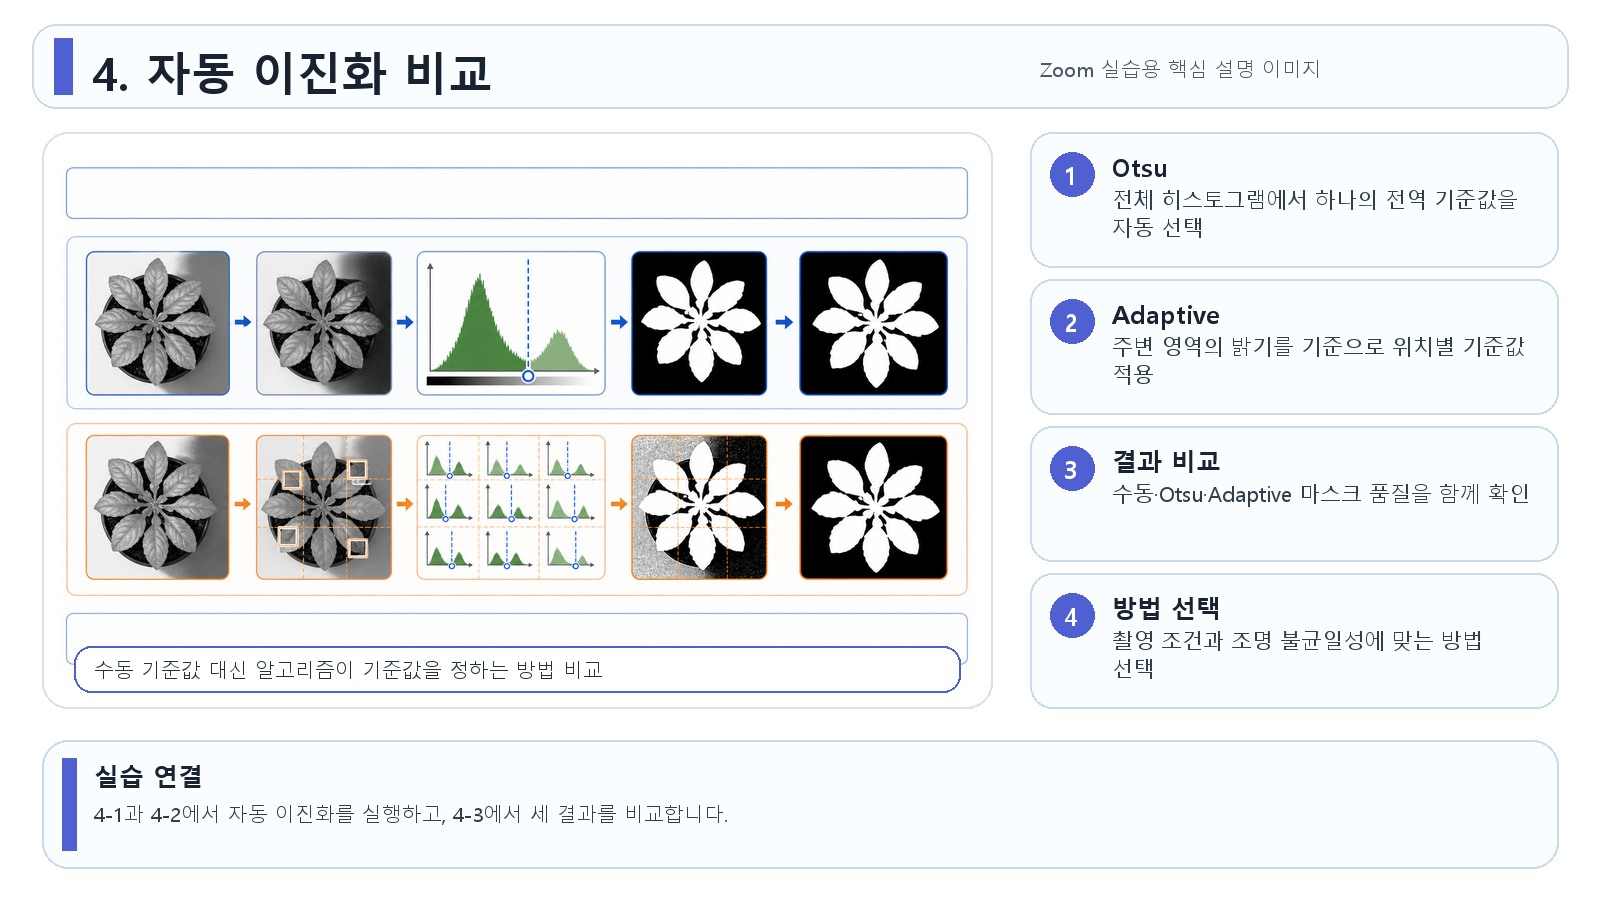</p>
> **Zoom 실습용 이미지 해설**
>
> 이 장의 두 이미지는 Otsu 방법과 적응형 임계값의 차이를 설명합니다. Otsu는 이미지 전체의 히스토그램을 보고 하나의 기준값을 자동으로 찾습니다. 적응형 임계값은 이미지의 작은 주변 영역을 기준으로 위치마다 다른 기준값을 적용합니다.
>
> **강사 진행 포인트:** "자동 방법이라고 항상 정답은 아닙니다. 조명과 배경이 일정하면 Otsu가 간단하고, 밝기가 위치마다 달라지면 적응형 방법이 도움이 될 수 있습니다. 하지만 최종 판단은 마스크 품질을 눈으로 확인하면서 해야 합니다."
>
> **실습 연결:** 4-1에서 Otsu 결과를 만들고, 4-2에서 적응형 결과를 만든 뒤, 4-3에서 수동 threshold와 함께 비교합니다.

수동 기준값은 원리를 이해하기 좋지만, 이미지마다 값을 바꿔야 할 수 있습니다. 자동 이진화는 기준값을 알고리즘이 정하게 하거나, 이미지의 위치마다 다른 기준을 적용합니다.

<details>
<summary><b>Otsu와 adaptive threshold 차이</b></summary>

- **Otsu:** 전체 이미지의 히스토그램을 보고 객체와 배경을 가장 잘 나누는 하나의 기준값을 찾습니다.
- **Adaptive threshold:** 이미지 전체가 아니라 주변 픽셀의 평균을 기준으로 삼습니다. 조명이 한쪽만 어둡거나 밝을 때 도움이 될 수 있습니다.
- 자동 방법도 완벽하지 않습니다. 표현체 분석에서는 결과 마스크가 계측 목적에 맞는지 눈으로 확인하는 과정이 중요합니다.

</details>


## 4-1. Otsu 자동 이진화

**이 셀에서 하는 일:** 이미지 전체의 히스토그램을 이용해 자동 기준값을 찾습니다.

**관찰 포인트:** 수동 기준값 결과와 비교해 식물 영역이 더 많이 또는 더 적게 선택되는지 보세요.


In [ ]:
#@title 04-1. Otsu 자동 이진화 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('channel_img', 'pcv', 'show_grid', 'mask_summary', hint='02-3. 분석 채널 선택')

otsu_object_type = "light" #@param ["light", "dark"]

auto_thresh = pcv.threshold.otsu(gray_img=channel_img, object_type=otsu_object_type)
mask_summary(auto_thresh, "Otsu 자동 마스크")
show_grid([channel_img, auto_thresh], [channel_choice, "Otsu mask"], figsize=(8.5, 4))


## 4-2. 적응형 이진화

**이 셀에서 하는 일:** 주변 픽셀의 평균을 기준으로 위치별 threshold를 적용합니다.

**바꿔볼 값:** `adaptive_ksize`는 주변을 얼마나 넓게 볼지, `adaptive_offset`은 기준을 얼마나 보정할지 정합니다.


In [ ]:
#@title 04-2. 적응형 이진화 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('channel_img', 'pcv', 'show_grid', 'mask_summary', hint='02-3. 분석 채널 선택')

adaptive_ksize = 99 #@param {type:"slider", min:3, max:201, step:2}
adaptive_offset = -2 #@param {type:"slider", min:-30, max:30, step:1}
adaptive_object_type = "light" #@param ["light", "dark"]

adaptive_ksize = int(adaptive_ksize)
if adaptive_ksize % 2 == 0:
    adaptive_ksize += 1

adapt_thresh = pcv.threshold.mean(
    gray_img=channel_img,
    ksize=adaptive_ksize,
    offset=adaptive_offset,
    object_type=adaptive_object_type,
)

print(f"ksize={adaptive_ksize}, offset={adaptive_offset}, object_type={adaptive_object_type}")
mask_summary(adapt_thresh, "적응형 이진화 마스크")
show_grid([channel_img, adapt_thresh], [channel_choice, "Adaptive mean mask"], figsize=(8.5, 4))


## 4-3. 세 가지 마스크 비교

**이 셀에서 하는 일:** 수동 threshold, Otsu, adaptive 결과를 한 줄로 비교합니다.

**관찰 포인트:** 앞으로 계측에 사용할 기준 마스크는 기본적으로 `thresh_mask`입니다. 결과가 좋지 않으면 3-1 셀로 돌아가 기준값을 다시 조절하세요.


In [ ]:
#@title 04-3. 세 가지 마스크 비교 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('thresh_mask', 'auto_thresh', 'adapt_thresh', 'show_grid', hint='03-1, 04-1, 04-2')

show_grid(
    [thresh_mask, auto_thresh, adapt_thresh],
    ["Manual threshold", "Otsu", "Adaptive mean"],
    figsize=(12, 4),
)


## 4-4. 계측에 사용할 마스크 선택

**이 셀에서 하는 일:** 앞에서 비교한 마스크 중 계측에 사용할 하나를 선택합니다.

**왜 필요한가요:** 수동 threshold, 범위 threshold, RGB 범위, Otsu, adaptive는 모두 장단점이 다릅니다. 교육생이 직접 고른 마스크가 이후 노이즈 제거와 계측으로 이어지게 합니다.


In [ ]:
#@title 04-4. 계측에 사용할 마스크 선택 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("thresh_mask", "range_mask", "rgb_mask", "auto_thresh", "adapt_thresh", "show_grid", "mask_summary", hint="03-1부터 04-3까지")

measurement_mask_choice = "manual_threshold" #@param ["manual_threshold", "gray_range", "rgb_range", "otsu", "adaptive"]

mask_options = {
    "manual_threshold": thresh_mask,
    "gray_range": range_mask,
    "rgb_range": rgb_mask,
    "otsu": auto_thresh,
    "adaptive": adapt_thresh,
}
selected_mask = mask_options[measurement_mask_choice]
print(f"선택한 계측 마스크: {measurement_mask_choice}")
mask_summary(selected_mask, "계측 선택 마스크")
show_grid([selected_mask], ["계측에 사용할 마스크"], cmaps=["gray"], figsize=(5.5, 4.5))


# 5. 노이즈 제거, ROI 지정, 형질 계측

<p>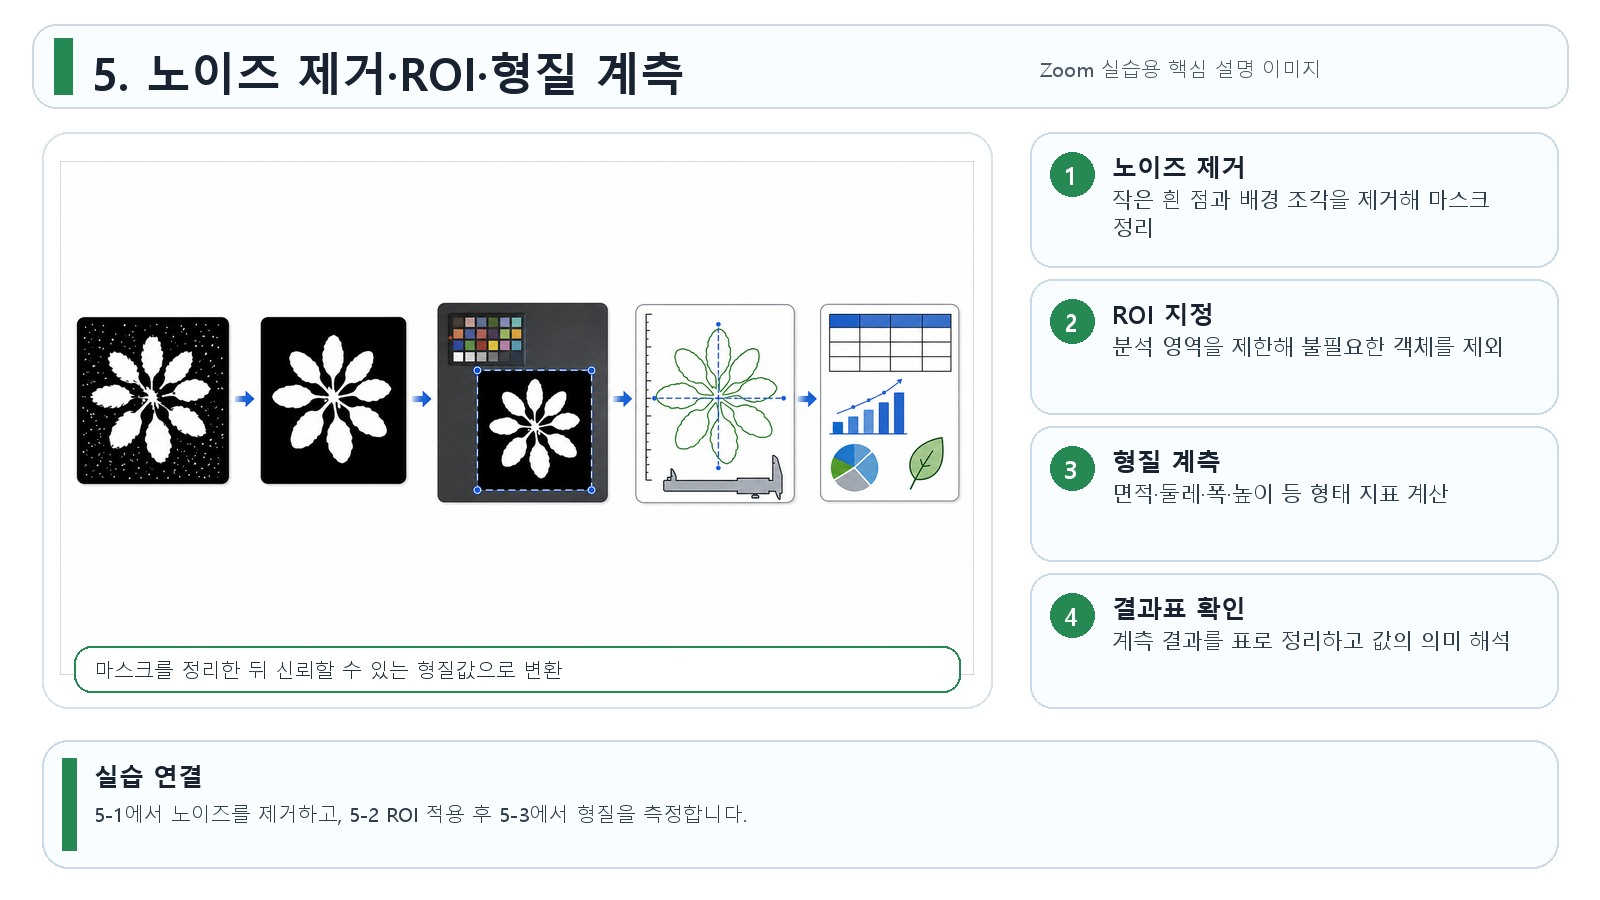</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 분할 마스크를 바로 측정하지 않고 정리한 뒤 계측하는 과정을 보여줍니다. 작은 흰 점은 노이즈일 수 있으므로 제거하고, ROI는 분석 대상이 아닌 컬러체커나 배경을 제외하는 역할을 합니다. 마지막에는 정리된 식물 마스크에서 면적, 둘레, 폭, 높이 같은 형질을 측정합니다.
>
> **강사 진행 포인트:** "표현체 분석에서 중요한 것은 마스크를 만드는 것에서 끝나지 않고, 신뢰할 수 있는 숫자로 바꾸는 것입니다. 잘못 들어간 작은 배경 조각도 면적과 둘레를 바꿀 수 있습니다."
>
> **실습 연결:** 5-1은 노이즈 제거, 5-2는 ROI 제한, 5-3은 최종 형질 측정과 표 확인입니다.

분할 마스크가 만들어졌다고 바로 계측하면 안 됩니다. 작은 먼지, 배경 조각, 컬러체커 같은 분석 대상이 아닌 영역이 같이 들어가면 면적과 둘레가 달라집니다. 그래서 **노이즈 제거**와 **ROI 지정**을 거친 뒤 계측합니다.

<details>
<summary><b>이번 단계에서 보는 형질</b></summary>

- **area:** 마스크에 포함된 픽셀 수입니다. 식물 면적의 기본 지표입니다.
- **convex hull area:** 객체를 감싸는 볼록 껍질의 면적입니다.
- **solidity:** `area / convex_hull_area`입니다. 잎 사이 빈 공간이 많으면 낮아질 수 있습니다.
- **perimeter:** 객체 경계의 길이입니다. 경계가 복잡하거나 노이즈가 많으면 커질 수 있습니다.

</details>


## 5-1. 작은 노이즈 제거

**이 셀에서 하는 일:** 4-4에서 선택한 마스크 안의 작은 점이나 조각을 제거해 `fill_mask`를 만듭니다.

**바꿔볼 값:** `fill_size`를 키우면 작은 조각이 더 많이 제거됩니다. 너무 키우면 필요한 식물 부분도 사라질 수 있습니다. 값을 바꾸면 5-1부터 5-3까지 다시 실행하세요.


In [ ]:
#@title 05-1. 작은 노이즈 제거 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("selected_mask", "pcv", "show_grid", "mask_summary", hint="04-4. 계측에 사용할 마스크 선택")
fill_size = 1000 #@param {type:"slider", min:0, max:5000, step:100}

fill_mask = selected_mask if fill_size <= 0 else pcv.fill(bin_img=selected_mask, size=fill_size)
mask_summary(fill_mask, "노이즈 제거 후 마스크")
show_grid([selected_mask, fill_mask], ["선택 마스크", "노이즈 제거 후"], figsize=(8.5, 4))


## 5-2. ROI로 분석 영역 제한

**이 셀에서 하는 일:** 컬러체커와 불필요한 배경을 제외하고, 식물이 있는 영역만 남겨 `kept_mask`를 만듭니다.

**바꿔볼 값:** ROI 위치와 크기를 바꿔서 컬러체커가 빠지고 식물 영역은 남는지 확인하세요.


In [ ]:
#@title 05-2. ROI로 분석 영역 제한 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars('fill_mask', 'bounded_crop', 'pcv', 'show_grid', 'mask_summary', hint='05-1. 작은 노이즈 제거')

roi_x = 540 #@param {type:"slider", min:0, max:2500, step:20}
roi_y = 0 #@param {type:"slider", min:0, max:2900, step:20}
roi_w = 1500 #@param {type:"slider", min:100, max:2500, step:20}
roi_h = 2500 #@param {type:"slider", min:100, max:2900, step:20}
roi_type = "partial" #@param ["partial", "cutto", "within"]

_, roi_info = bounded_crop(fill_mask, roi_x, roi_y, roi_w, roi_h)
roi = pcv.roi.rectangle(
    img=fill_mask,
    x=roi_info["x"],
    y=roi_info["y"],
    h=roi_info["h"],
    w=roi_info["w"],
)
kept_mask = pcv.roi.quick_filter(mask=fill_mask, roi=roi, roi_type=roi_type)

print("적용된 ROI:", roi_info)
mask_summary(kept_mask, "ROI 적용 후 마스크")
show_grid([fill_mask, kept_mask], ["After fill", "ROI filtered"], figsize=(8.5, 4))


## 5-3. 식물 형질 측정

**이 셀에서 하는 일:** 최종 마스크를 이용해 면적, 둘레, 폭, 높이 등을 계산합니다.

**관찰 포인트:** 앞 단계의 threshold, fill, ROI 값을 바꾸면 이 표의 숫자도 달라집니다. 이것이 분할 품질이 표현형 계측값에 영향을 주는 이유입니다.


In [ ]:
#@title 05-3. 식물 형질 측정 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("crop_img", "kept_mask", "pcv", "clear_pcv_outputs", "size_table_from_outputs", "show_grid", "RESULT_DIR", hint="05-2. ROI로 분석 영역 제한")
measurement_label = "plant" #@param {type:"string"}
max_rows_to_show = 5 #@param {type:"slider", min:1, max:20, step:1}

labeled_plant, n_plant = pcv.create_labels(mask=kept_mask)
if n_plant == 0:
    raise RuntimeError("분석할 객체가 없습니다. threshold/마스크 선택/ROI 값을 조정한 뒤 5-1부터 다시 실행하세요.")

clear_pcv_outputs()
analysis_image = pcv.analyze.size(
    img=crop_img,
    labeled_mask=labeled_plant,
    n_labels=n_plant,
    label=measurement_label,
)

show_grid([analysis_image], ["식물 형질 측정 결과"], figsize=(6, 5))
trait_table = size_table_from_outputs(label_prefix=measurement_label, max_rows=max_rows_to_show, sort_by_area=True)
trait_csv = RESULT_DIR / "plant_traits.csv"
trait_table.to_csv(trait_csv, index=False, encoding="utf-8-sig")
print(f"결과 저장: {trait_csv}")
print("주의: area_px는 실제 cm²가 아니라 선택된 픽셀 수입니다.")
display(trait_table)


# 6. 지도학습 기반 병징 분할: Naive Bayes

<p>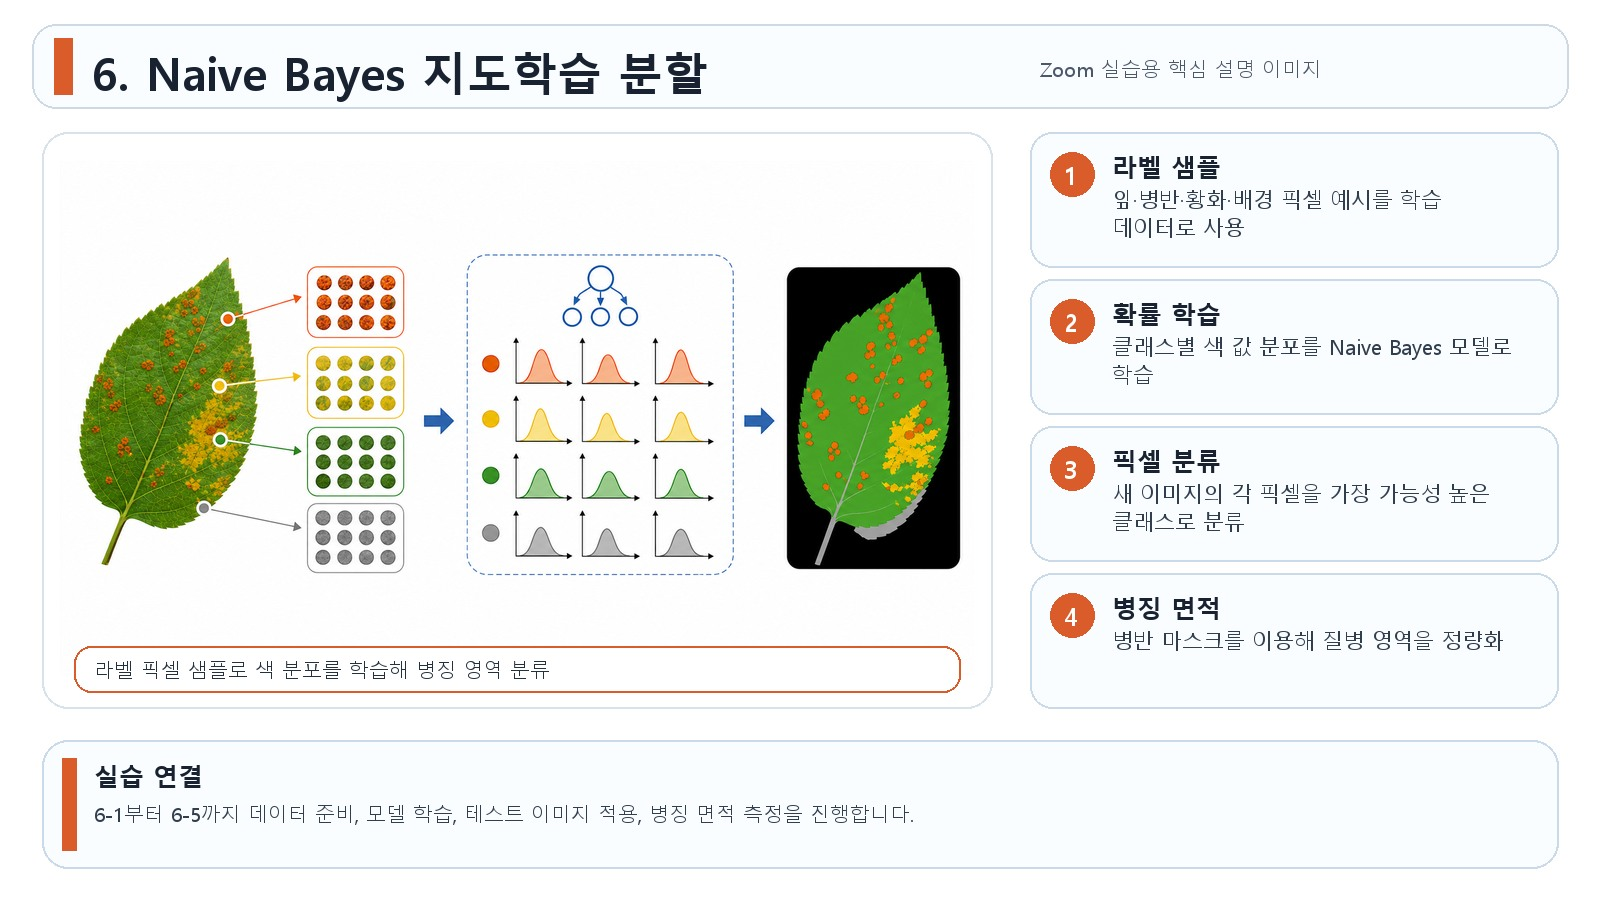</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 사람이 미리 표시한 픽셀 샘플을 이용해 병징 영역을 분류하는 지도학습 흐름을 보여줍니다. 잎, 병반, 황화, 배경처럼 클래스가 정해져 있고, Naive Bayes 모델은 각 클래스의 색 분포를 학습한 뒤 새 픽셀이 어느 클래스에 가까운지 판단합니다.
>
> **강사 진행 포인트:** "지도학습은 정답 예시를 주고 모델을 학습시키는 방식입니다. 여기서는 딥러닝처럼 큰 모델을 쓰는 것이 아니라, 색 분포를 빠르게 학습하는 간단한 분류기를 사용합니다."
>
> **실습 연결:** 6-1에서 예제 데이터를 받고, 6-2에서 모델을 학습한 뒤, 6-3과 6-4에서 학습 이미지와 새 이미지에 적용합니다. 6-5에서는 병징 면적을 수치화합니다.

이번 장에서는 사람이 미리 표시해 둔 픽셀 예시를 사용해 병징 영역을 분할합니다. 여기서는 잎, 병반, 황화, 배경 픽셀의 색 값 분포를 학습하고 새 이미지의 픽셀이 어느 클래스에 가까운지 판단합니다.

<details>
<summary><b>Naive Bayes 모델이란?</b></summary>

Naive Bayes는 각 클래스별로 관측값이 나타날 확률을 계산하고, 새 데이터가 어느 클래스일 가능성이 큰지 고르는 분류 모델입니다. 여기서는 픽셀의 색 값이 입력이고, `leaf`, `pustule`, `chlorosis`, `background`가 출력 클래스입니다.

**장점**

- 학습이 빠르고 구현이 단순합니다.
- 적은 수의 픽셀 샘플로도 색 기반 분할을 시작할 수 있습니다.
- 어떤 클래스가 어떤 색 분포를 갖는지 비교적 해석하기 쉽습니다.

**주의점**

- 조명, 그림자, 품종, 촬영 조건이 바뀌면 색 분포가 달라질 수 있습니다.
- RGB 채널이 서로 독립적이라고 단순화하기 때문에 복잡한 질감이나 형태 정보는 잘 반영하지 못합니다.

**다른 대표 모델**

- 전통적 방법: threshold, morphology, watershed
- 일반 머신러닝: k-NN, SVM, Random Forest
- 딥러닝/비전 모델: U-Net, Mask R-CNN, Segment Anything 계열

</details>


## 6-1. 지도학습 예제 데이터 준비

**이 셀에서 하는 일:** 밀 녹병 예제 이미지와 픽셀 샘플 파일을 다운로드합니다.

**관찰 포인트:** 처음 실행하면 다운로드 메시지가 보이고, 다시 실행하면 기존 폴더를 재사용합니다.


In [ ]:
#@title 06-1. 지도학습 예제 데이터 준비 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("ensure_github_repo", "read_plantcv_image", "WORK_DIR", "DATA_DIR", "DATA_MANIFEST", "pcv", "show_grid", hint="00-6. 예제 데이터 다운로드")

supervised_repo_url = DATA_MANIFEST["supervised"]["repo"] #@param {type:"string"}

supervised_dir = ensure_github_repo(
    supervised_repo_url,
    DATA_DIR / "plantcv-tutorial-supervised-ml",
    required_paths=DATA_MANIFEST["supervised"]["required"],
    ref=DATA_MANIFEST["supervised"]["commit"],
)
train_image_path = supervised_dir / "img" / "wheat_rust1.png"

color_img, path, filename = read_plantcv_image(train_image_path, description="Naive Bayes 학습 이미지")
print(f"학습 예제 이미지: {train_image_path}")
show_grid([color_img], ["학습 이미지"], figsize=(6, 4.5))


## 6-2. Naive Bayes 모델 학습

**이 셀에서 하는 일:** 미리 준비된 픽셀 샘플을 이용해 클래스별 색 분포 모델을 학습합니다.

**관찰 포인트:** 여기서 학습한 모델 파일이 다음 셀에서 이미지 분류에 사용됩니다.


In [ ]:
#@title 06-2. Naive Bayes 모델 학습 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("supervised_dir", "ensure_file_exists", "naive_bayes_multiclass", "RESULT_DIR", hint="06-1. 지도학습 예제 데이터 준비")

make_training_plots = True #@param {type:"boolean"}

samples_file = ensure_file_exists(supervised_dir / "example_data" / "pixel_values.txt", "Naive Bayes 픽셀 샘플 파일")
nb_model_file = RESULT_DIR / "nb_model_rise.txt"

print("모델 학습 중입니다. 환경에 따라 1분 내외가 걸릴 수 있습니다.")
naive_bayes_multiclass(
    samples_file=str(samples_file),
    outfile=str(nb_model_file),
    mkplots=make_training_plots,
)

ensure_file_exists(nb_model_file, "Naive Bayes 모델 파일")
print(f"모델 저장 위치: {nb_model_file}")


## 6-3. 학습 이미지에서 분류 결과 확인

**이 셀에서 하는 일:** 학습에 사용한 이미지에 모델을 적용해 각 픽셀을 `leaf`, `pustule`, `chlorosis`로 분류합니다.

**관찰 포인트:** 주황색 병반과 노란 황화 영역이 잎과 구분되는지 확인하세요.


In [ ]:
#@title 06-3. 학습 이미지에서 분류 결과 확인 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("color_img", "nb_model_file", "pcv", "show_grid", "mask_summary", hint="06-2. Naive Bayes 모델 학습")

masks = pcv.naive_bayes_classifier(rgb_img=color_img, pdf_file=str(nb_model_file))
expected_labels = ["leaf", "pustule", "chlorosis"]
missing_labels = [label for label in expected_labels if label not in masks]
if missing_labels:
    raise RuntimeError(f"분류 결과에 필요한 라벨이 없습니다: {missing_labels}")
for label in expected_labels:
    mask_summary(masks[label], f"{label} 마스크")
merged_mask = pcv.visualize.colorize_masks(
    masks=[masks["leaf"], masks["pustule"], masks["chlorosis"]],
    colors=["green", "red", "yellow"],
)

print("색상 의미: green=leaf, red=pustule, yellow=chlorosis")
show_grid([color_img, merged_mask], ["Training image", "Classified mask"], figsize=(10, 4.5))


## 6-4. 새 이미지에 분류기 적용

**이 셀에서 하는 일:** 학습에 사용하지 않은 테스트 이미지에 같은 모델을 적용합니다.

**관찰 포인트:** 지도학습 모델의 핵심은 새 이미지에서도 비슷한 규칙이 작동하는지 확인하는 것입니다.


In [ ]:
#@title 06-4. 새 이미지에 분류기 적용 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("supervised_dir", "nb_model_file", "read_plantcv_image", "pcv", "show_grid", "mask_summary", hint="06-2. Naive Bayes 모델 학습")

test_image_path = supervised_dir / "img" / "wheat_rust2.png"
color_img2, path2, filename2 = read_plantcv_image(test_image_path, description="Naive Bayes 테스트 이미지")

masks2 = pcv.naive_bayes_classifier(rgb_img=color_img2, pdf_file=str(nb_model_file))
expected_labels = ["leaf", "pustule", "chlorosis"]
missing_labels = [label for label in expected_labels if label not in masks2]
if missing_labels:
    raise RuntimeError(f"테스트 이미지 분류 결과에 필요한 라벨이 없습니다: {missing_labels}")
for label in expected_labels:
    mask_summary(masks2[label], f"테스트 {label} 마스크")
merged_mask2 = pcv.visualize.colorize_masks(
    masks=[masks2["leaf"], masks2["pustule"], masks2["chlorosis"]],
    colors=["green", "red", "yellow"],
)

show_grid([color_img2, merged_mask2], ["Test image", "Classified mask"], figsize=(10, 4.5))


## 6-5. 병징 영역 면적 측정

**이 셀에서 하는 일:** 선택한 클래스의 마스크를 이용해 면적을 계산합니다.

**바꿔볼 값:** `disease_label`을 `pustule`, `chlorosis`, `leaf`로 바꿔 면적이 어떻게 달라지는지 확인하세요.


In [ ]:
#@title 06-5. 병징 영역 면적 측정 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("color_img2", "masks2", "pcv", "clear_pcv_outputs", "size_table_from_outputs", "show_grid", "RESULT_DIR", hint="06-4. 새 이미지에 분류기 적용")
disease_label = "pustule" #@param ["pustule", "chlorosis", "leaf"]

labeled_disease, n_disease = pcv.create_labels(mask=masks2[disease_label])
if n_disease == 0:
    raise RuntimeError(f"{disease_label} 영역이 없습니다. 06-4 분류 결과를 확인하세요.")

clear_pcv_outputs()
disease_analysis = pcv.analyze.size(
    img=color_img2,
    labeled_mask=labeled_disease,
    n_labels=n_disease,
    label=disease_label,
)

show_grid([color_img2, masks2[disease_label], disease_analysis], ["테스트 이미지", disease_label, "병징 측정"], figsize=(13, 4.2))
disease_table = size_table_from_outputs(label_prefix=disease_label, max_rows=10, sort_by_area=True)
disease_csv = RESULT_DIR / "disease_traits.csv"
disease_table.to_csv(disease_csv, index=False, encoding="utf-8-sig")
print(f"결과 저장: {disease_csv}")
print("주의: area_px는 실제 cm²가 아니라 선택된 픽셀 수입니다.")
display(disease_table)


# 7. 비지도학습 기반 식물 분할: k-means

<p>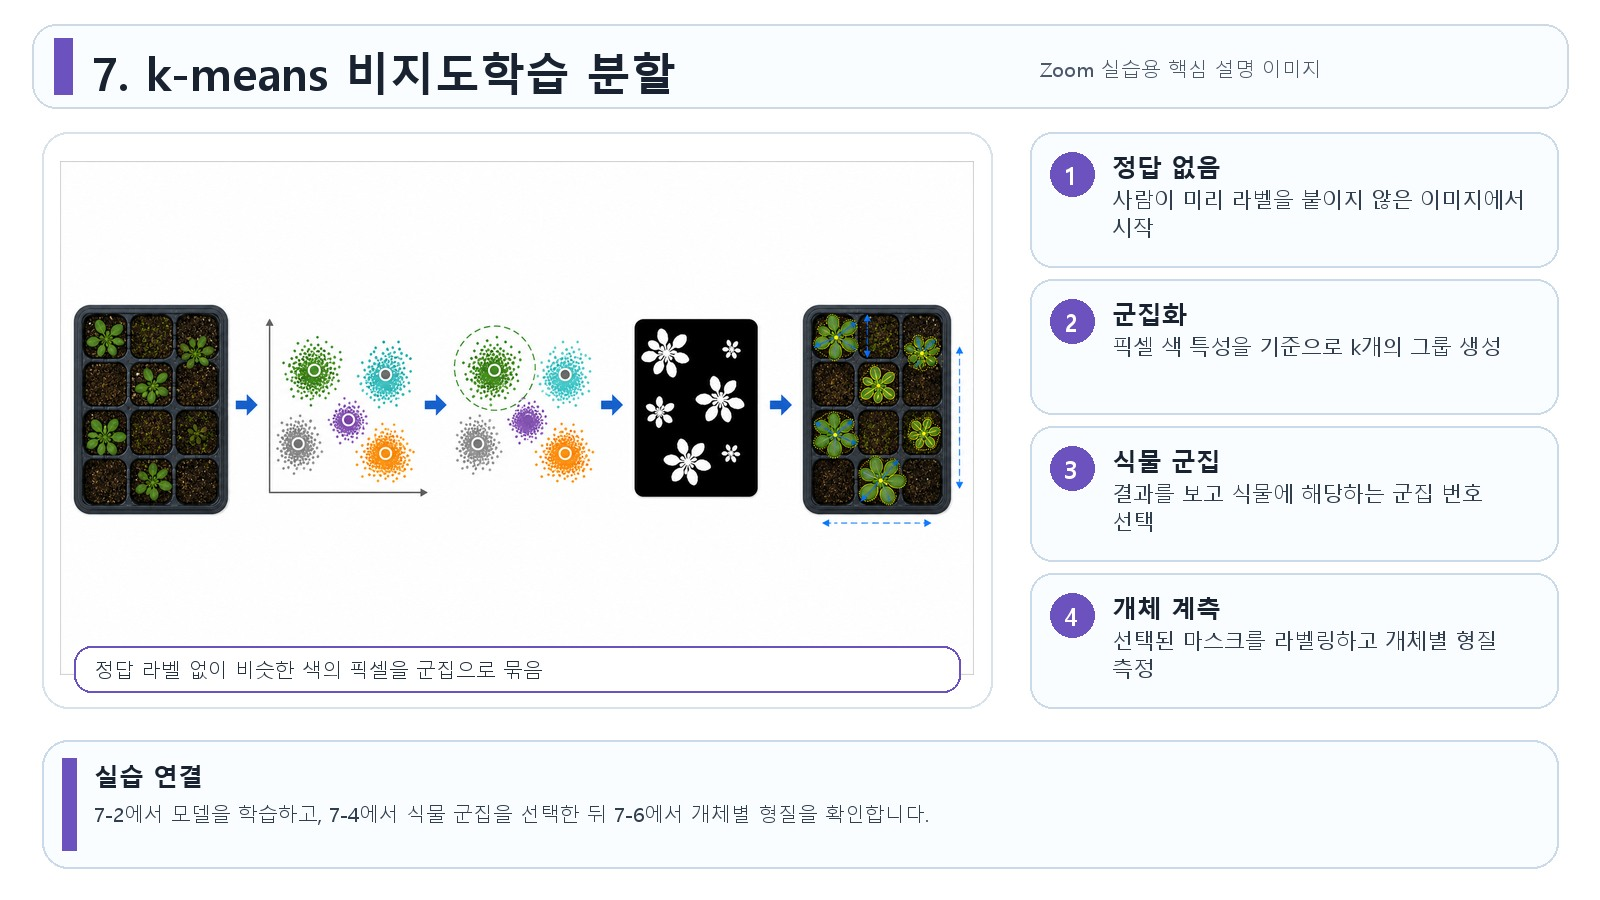</p>
> **Zoom 실습용 이미지 해설**
>
> 이 그림은 정답 라벨 없이 픽셀을 비슷한 색끼리 묶는 k-means 흐름을 보여줍니다. 픽셀은 색 특성 공간에서 여러 군집으로 나뉘고, 그중 식물에 해당하는 군집을 사람이 선택해 마스크로 사용합니다.
>
> **강사 진행 포인트:** "비지도학습은 정답 라벨 없이 패턴을 찾는 방식입니다. 다만 군집 번호 자체에는 '식물'이라는 의미가 붙어 있지 않기 때문에, 결과를 보고 어떤 군집을 선택할지 사람이 해석해야 합니다."
>
> **실습 연결:** 7-2에서 k-means를 학습하고, 7-3에서 군집 번호를 예측합니다. 7-4에서 식물 군집을 선택하고, 7-5와 7-6에서 ROI와 형질 측정을 진행합니다.

k-means는 정답 라벨 없이 픽셀들을 비슷한 색끼리 `k`개 그룹으로 묶습니다. 사람이 미리 `이 픽셀은 식물`, `이 픽셀은 배경`이라고 알려주지 않아도 군집을 만들 수 있지만, 만들어진 군집 중 어떤 번호가 식물인지 확인하고 선택해야 합니다.

<details>
<summary><b>k-means에서 직접 바꿔볼 값</b></summary>

- **k:** 몇 개의 색 그룹으로 나눌지 정합니다. 너무 작으면 식물과 배경이 섞이고, 너무 크면 비슷한 식물 영역도 여러 군집으로 쪼개질 수 있습니다.
- **selected_categories:** k-means가 만든 군집 번호 중 식물로 볼 번호입니다. 결과 마스크를 보고 바꿔보세요.
- **ROI:** 트레이 전체가 아니라 계측할 식물이 있는 영역만 남기는 단계입니다.
- **라벨 수:** 연결된 마스크 조각의 수입니다. 잎이 서로 떨어져 있으면 실제 식물 개체보다 많게 나올 수 있으므로, 면적 필터와 결과 이미지를 함께 확인해야 합니다.

</details>


## 7-1. 비지도학습 예제 데이터 준비

**이 셀에서 하는 일:** Arabidopsis 트레이 이미지를 포함한 k-means 예제 데이터를 다운로드합니다.

**관찰 포인트:** 지도학습 장과 다르게 정답 라벨 파일 없이 이미지 색 분포만 사용합니다.


In [ ]:
#@title 07-1. 비지도학습 예제 데이터 준비 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("ensure_github_repo", "read_plantcv_image", "WORK_DIR", "DATA_DIR", "DATA_MANIFEST", "pcv", "show_grid", hint="00-6. 예제 데이터 다운로드")

unsupervised_repo_url = DATA_MANIFEST["unsupervised"]["repo"] #@param {type:"string"}

unsupervised_dir = ensure_github_repo(
    unsupervised_repo_url,
    DATA_DIR / "plantcv-tutorial-unsupervised-ml",
    required_paths=DATA_MANIFEST["unsupervised"]["required"],
    ref=DATA_MANIFEST["unsupervised"]["commit"],
)
kmeans_image_path = unsupervised_dir / "img" / "10.9.1.230_pos-165-001-004_2019-11-01-10-05.jpg"

color_img_k, imgpath, imgname = read_plantcv_image(kmeans_image_path, description="k-means 예제 이미지")
print(f"k-means 예제 이미지: {kmeans_image_path}")
show_grid([color_img_k], ["Arabidopsis 트레이 이미지"], figsize=(6, 5))


## 7-2. k-means 모델 학습

**이 셀에서 하는 일:** 이미지 폴더의 픽셀을 이용해 색 기반 군집 모델을 학습합니다.

**바꿔볼 값:** `k_clusters`를 바꾸면 색 그룹 개수가 달라집니다. 값이 달라지면 다음 셀의 군집 번호 해석도 달라질 수 있습니다.


In [ ]:
#@title 07-2. k-means 모델 학습 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("unsupervised_dir", "RESULT_DIR", "train_kmeans", "working_directory", hint="07-1. 비지도학습 예제 데이터 준비")
k_clusters = 10 #@param {type:"slider", min:3, max:14, step:1}
patch_size = 1 #@param {type:"slider", min:1, max:5, step:1}
kmeans_seed = 1 #@param {type:"integer"}

kmeans_model_file = RESULT_DIR / f"kmeans_k{k_clusters}_p{patch_size}_seed{kmeans_seed}.fit"
print("k-means 모델 학습 중입니다. 환경에 따라 1~3분 정도 걸릴 수 있습니다.")
with working_directory(unsupervised_dir):
    kmeans_model = train_kmeans(img_dir="./img/", k=k_clusters, patch_size=patch_size, seed=kmeans_seed, out_path=str(kmeans_model_file))

ensure_file_exists(kmeans_model_file, "k-means 모델 파일")
print(kmeans_model)
print(f"모델 저장 위치: {kmeans_model_file}")


## 7-3. 각 픽셀의 군집 번호 예측

**이 셀에서 하는 일:** 학습된 k-means 모델로 이미지의 각 픽셀이 몇 번 군집에 속하는지 예측합니다.

**관찰 포인트:** 색이 비슷한 영역끼리 같은 번호로 묶입니다. 이 번호는 의미가 고정된 라벨이 아니라, 학습 결과에 따라 붙은 군집 번호입니다.


In [ ]:
#@title 07-3. 각 픽셀의 군집 번호 예측 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("unsupervised_dir", "color_img_k", "kmeans_model_file", "pcv", "working_directory", "show_grid", hint="07-2. k-means 모델 학습")
with working_directory(unsupervised_dir):
    labeled_img = pcv.predict_kmeans(img=color_img_k, model_path=str(kmeans_model_file), patch_size=patch_size)

print(f"군집 라벨 이미지 shape: {labeled_img.shape}")
show_grid([color_img_k, labeled_img], ["원본 이미지", "k-means 군집 라벨"], cmaps=[None, "nipy_spectral"], figsize=(10, 4.5))


## 7-4. 군집별 마스크 미리보기

**이 셀에서 하는 일:** k-means가 만든 각 군집 번호를 개별 마스크로 펼쳐서 보여줍니다.

**관찰 포인트:** 군집 번호는 고정 의미가 아니라 학습 결과에 따라 붙는 번호입니다. 여기서 식물에 해당하는 번호를 눈으로 확인한 뒤 다음 셀에서 선택합니다.


In [ ]:
#@title 07-4. 군집별 마스크 미리보기 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("labeled_img", "k_clusters", "pcv", "plt", "np", hint="07-3. 각 픽셀의 군집 번호 예측")

cols = min(5, k_clusters)
rows = int(np.ceil(k_clusters / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.0 * cols, 2.6 * rows))
axes = np.asarray(axes).reshape(-1)
for cluster_idx in range(k_clusters):
    ax = axes[cluster_idx]
    cluster_mask = pcv.mask_kmeans(labeled_img=labeled_img, k=k_clusters, cat_list=[cluster_idx])
    ax.imshow(cluster_mask, cmap="gray")
    ax.set_title(f"군집 {cluster_idx}")
    ax.axis("off")
for ax in axes[k_clusters:]:
    ax.axis("off")
plt.tight_layout()
plt.show()
plt.close(fig)
print("식물처럼 보이는 군집 번호를 다음 셀의 selected_categories에 쉼표로 입력하세요. 예: 3,5")


## 7-5. 식물 군집 선택

**이 셀에서 하는 일:** 군집 번호 중 식물에 해당한다고 판단되는 번호를 선택해 마스크를 만듭니다.

**바꿔볼 값:** `selected_categories`에 `5` 또는 `3,5`처럼 쉼표로 여러 번호를 입력할 수 있습니다. 바로 위 군집별 미리보기 셀을 보고 선택하세요.


In [ ]:
#@title 07-5. 식물 군집 선택 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("labeled_img", "parse_int_list", "pcv", "show_grid", "mask_summary", hint="07-4. 군집별 마스크 미리보기")
selected_categories = "5" #@param {type:"string"}

cat_list = parse_int_list(selected_categories, minimum=0, maximum=k_clusters - 1, default=[min(5, k_clusters - 1)])
mask_k = pcv.mask_kmeans(labeled_img=labeled_img, k=k_clusters, cat_list=cat_list)

print(f"선택한 군집 번호: {cat_list}")
mask_summary(mask_k, "선택 군집 마스크")
show_grid([labeled_img, mask_k], ["k-means 라벨", "선택 군집 마스크"], cmaps=["nipy_spectral", "gray"], figsize=(9, 4.5))


## 7-6. ROI 지정과 다중 개체 라벨 생성

**이 셀에서 하는 일:** 분석할 영역만 남기고, 연결된 마스크 조각마다 번호를 붙입니다.

**관찰 포인트:** 라벨 수는 실제 식물 수와 항상 같지 않습니다. 잎이 떨어져 보이면 한 식물이 여러 조각으로 계산될 수 있습니다.


In [ ]:
#@title 07-6. ROI 지정과 다중 개체 라벨 생성 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("mask_k", "bounded_crop", "pcv", "show_grid", "mask_summary", hint="07-5. 식물 군집 선택")
k_roi_x = 1000 #@param {type:"slider", min:0, max:3000, step:20}
k_roi_y = 0 #@param {type:"slider", min:0, max:2500, step:20}
k_roi_w = 2280 #@param {type:"slider", min:200, max:3500, step:20}
k_roi_h = 2464 #@param {type:"slider", min:200, max:2600, step:20}
k_roi_type = "partial" #@param ["partial", "cutto", "within"]

_, k_roi_info = bounded_crop(mask_k, k_roi_x, k_roi_y, k_roi_w, k_roi_h)
roi_k = pcv.roi.rectangle(
    img=mask_k,
    x=k_roi_info["x"],
    y=k_roi_info["y"],
    h=k_roi_info["h"],
    w=k_roi_info["w"],
)
kept_mask_k = pcv.roi.quick_filter(mask=mask_k, roi=roi_k, roi_type=k_roi_type)
labeled_objects, n_obj = pcv.create_labels(mask=kept_mask_k)
if n_obj == 0:
    raise RuntimeError("라벨링된 객체가 없습니다. 군집 번호 또는 ROI 값을 조정한 뒤 07-5부터 다시 실행하세요.")

print("적용된 ROI:", k_roi_info)
mask_summary(kept_mask_k, "k-means ROI 적용 후 마스크")
print(f"라벨링된 마스크 조각 수: {n_obj}")
show_grid([kept_mask_k, labeled_objects], ["ROI 적용 마스크", "라벨 객체"], cmaps=["gray", "nipy_spectral"], figsize=(9, 4.5))


## 7-7. 다중 개체 형질 측정

**이 셀에서 하는 일:** 라벨이 붙은 각 마스크 조각의 면적과 형태 지표를 계산합니다.

**바꿔볼 값:** `minimum_area_px`를 키우면 작은 조각이 표에서 제외됩니다. 처음에는 큰 객체 중심으로 보고, 나중에 기준을 낮춰 작은 조각까지 확인하세요.


In [ ]:
#@title 07-7. 다중 개체 형질 측정 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("color_img_k", "labeled_objects", "n_obj", "pcv", "clear_pcv_outputs", "size_table_from_outputs", "show_grid", "RESULT_DIR", hint="07-6. ROI 지정과 다중 개체 라벨 생성")
object_label_prefix = "arabidopsis" #@param {type:"string"}
max_objects_to_show = 10 #@param {type:"slider", min:1, max:30, step:1}
minimum_area_px = 1000 #@param {type:"slider", min:0, max:10000, step:100}
sort_by_area = True #@param {type:"boolean"}

if labeled_objects.shape[:2] != color_img_k.shape[:2]:
    raise RuntimeError(
        f"원본 이미지와 라벨 마스크 크기가 다릅니다. patch_size를 1로 두고 07-2부터 다시 실행하세요. "
        f"image={color_img_k.shape[:2]}, mask={labeled_objects.shape[:2]}"
    )

clear_pcv_outputs()
analysis_image_k = pcv.analyze.size(
    img=color_img_k,
    labeled_mask=labeled_objects,
    n_labels=n_obj,
    label=object_label_prefix,
)

show_grid([analysis_image_k], ["다중 개체 측정 결과"], figsize=(6, 5))
kmeans_table = size_table_from_outputs(
    label_prefix=object_label_prefix,
    max_rows=max_objects_to_show,
    min_area_px=minimum_area_px,
    sort_by_area=sort_by_area,
)
kmeans_csv = RESULT_DIR / "kmeans_object_traits.csv"
kmeans_table.to_csv(kmeans_csv, index=False, encoding="utf-8-sig")
print(f"결과 저장: {kmeans_csv}")
print("주의: area_px는 실제 cm²가 아니라 선택된 픽셀 수입니다.")
display(kmeans_table)


# 8. 마무리: 핵심 정리

<p>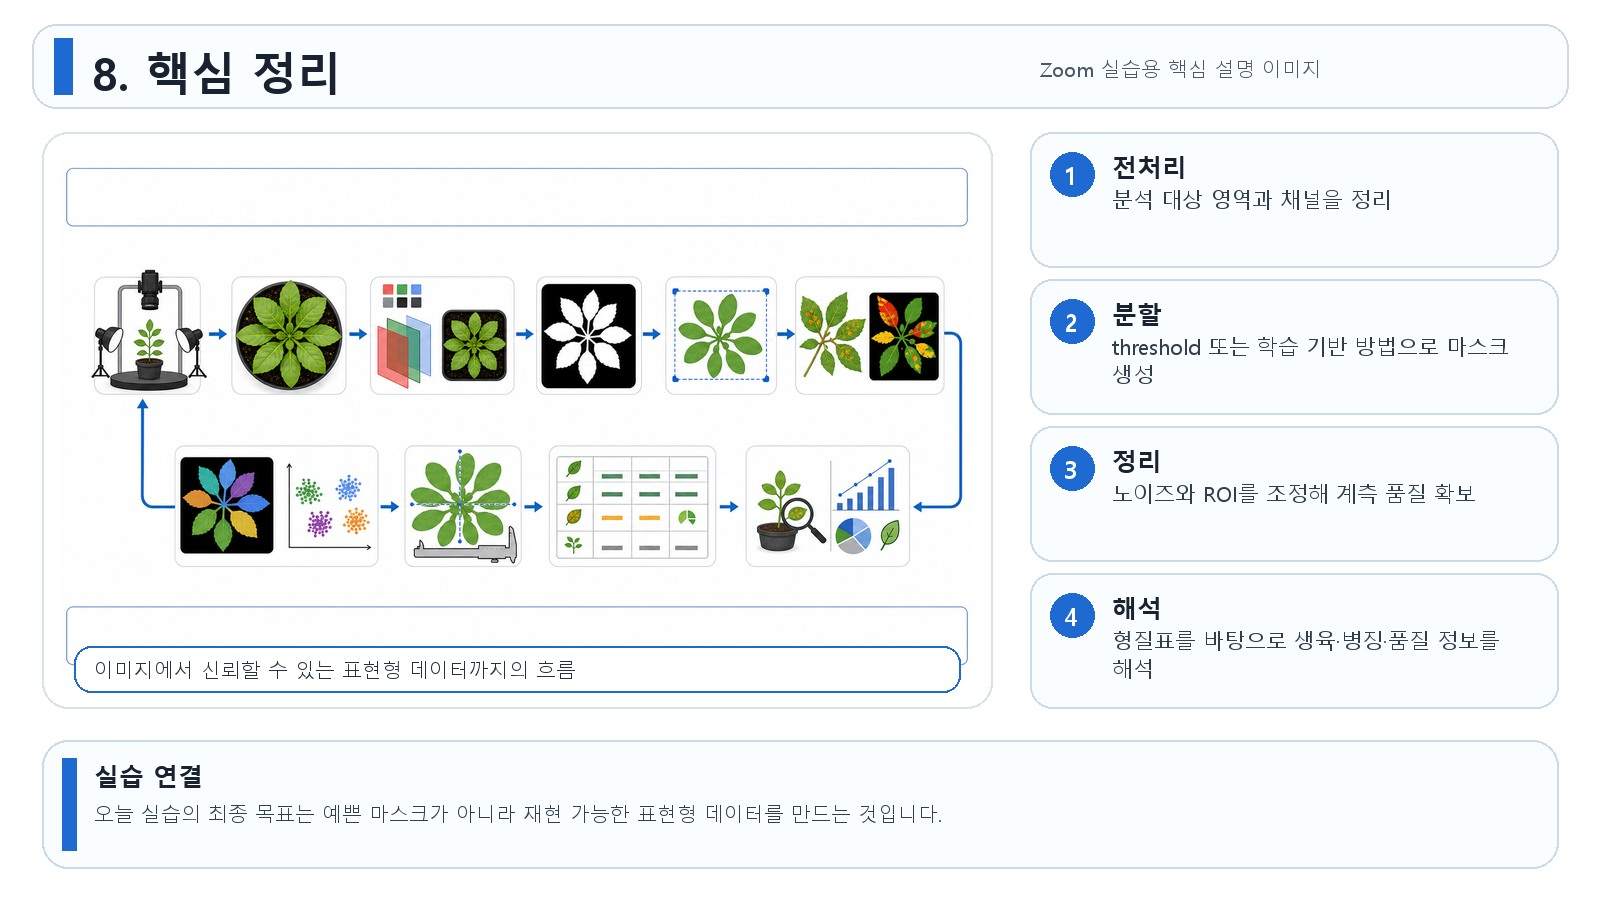</p>

오늘 실습에서 확인한 핵심은 다음과 같습니다.

- 표현체 분석의 출발점은 이미지이며, 분석 결과는 마스크 품질에 크게 좌우됩니다.
- RGB, 색공간, threshold, ROI는 객체를 배경에서 분리하기 위한 전처리 도구입니다.
- 계측값은 `area_px`처럼 픽셀 단위로 계산되며, 실제 물리 단위로 바꾸려면 별도의 scale calibration이 필요합니다.
- Naive Bayes는 라벨 샘플이 있을 때 병징처럼 의미가 있는 클래스를 분류하는 지도학습 예시입니다.
- k-means는 정답 라벨 없이 색이 비슷한 픽셀을 묶고, 사람이 군집 번호를 해석해 마스크를 만드는 비지도학습 예시입니다.

**내가 기록할 값**

| 항목 | 기록 |
|---|---|
| 선택한 계측 마스크 |  |
| threshold 또는 군집 번호 |  |
| `plant_traits.csv`의 주요 면적값 |  |
| 마스크 품질 판단 | 식물 대부분 포함 / 배경 일부 포함 / 객체 일부 누락 |
| 다음에 개선할 점 |  |


## 8-1. 결과 파일 묶음 생성

**이 셀에서 하는 일:** 실습 중 저장된 CSV와 모델 파일을 `rise_results.zip`으로 묶습니다.

**Colab 사용 팁:** 다운로드가 자동으로 뜨지 않으면 왼쪽 파일 패널에서 `/content/rise_phenotyping_practice/results` 폴더를 열어 직접 내려받으세요.


In [ ]:
#@title 08-1. 결과 파일 묶음 생성 { display-mode: "form" }
if "require_vars" not in globals():
    raise RuntimeError("먼저 0장 실행 환경 준비 셀을 위에서부터 실행하세요.")
require_vars("RESULT_DIR", "zipfile", hint="05-3, 06-5, 07-7 중 실행한 결과 셀")
DOWNLOAD_IN_COLAB = False #@param {type:"boolean"}

result_files = [p for p in RESULT_DIR.glob("*") if p.is_file()]
if not result_files:
    raise RuntimeError("결과 폴더에 저장된 파일이 없습니다. 05-3, 06-5, 07-7 중 하나 이상을 먼저 실행하세요.")

zip_path = RESULT_DIR / "rise_results.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for path in result_files:
        if path.name == zip_path.name:
            continue
        zf.write(path, arcname=path.name)

print(f"결과 묶음 저장: {zip_path}")
print("포함 파일:")
for path in sorted(result_files):
    if path.name != zip_path.name:
        print("-", path.name)

if DOWNLOAD_IN_COLAB:
    try:
        from google.colab import files
        files.download(str(zip_path))
    except Exception as exc:
        print("자동 다운로드를 시작하지 못했습니다. 왼쪽 파일 패널에서 직접 내려받으세요.")
        print(exc)
